# Evaluate Classification Results for HydraBLE Classification Hard

In [1]:
import os
from pathlib import Path

os.chdir(Path.cwd().parents[0])
print("Now in:", Path.cwd())

dataPathProcessed = str(Path.cwd()) + r"\data\csv" + r"\Processed Files\\"
logitsPath = str(Path.cwd()) + r"\out\modeling\logits_and_labels\\classification_hard\\"
plotPath = str(Path.cwd()) + r"\out\plots\modeling\classification_hard\\"
tablePath = str(Path.cwd()) + r"\out\tables\modeling\classification_hard\\"

Now in: C:\Users\stsax\OneDrive\Studium\9. Semester\Masterarbeit\Repository


In [2]:
import pandas as pd
from data_processing.LabelLut import LABEL_OTHER_DEVICE
from evaluation_framework import Experiment, StaticMetricCollection, OSCRCurve, AccuracyOpenSet

pkt_df_test = pd.read_parquet(dataPathProcessed + r"classification_dataset_hard_test.parquet")

known_labels = sorted(list(pkt_df_test['Label'].unique()))
known_labels.remove(LABEL_OTHER_DEVICE)

label_lut = {i: label for i, label in enumerate(known_labels)}
label_id_unknown = len(label_lut)
label_lut[label_id_unknown] = LABEL_OTHER_DEVICE

PRECISION = 4
H_VALS = (1,2,4,8)

config = StaticMetricCollection([OSCRCurve(unknown_label=label_id_unknown, precision=PRECISION),
                                 AccuracyOpenSet(unknown_label=label_id_unknown, precision=PRECISION, average='macro'),
                                 AccuracyOpenSet(unknown_label=label_id_unknown, precision=PRECISION, average='micro'),
                                 AccuracyOpenSet(unknown_label=label_id_unknown, precision=PRECISION, average='binary')]
                                )

In [3]:
label_lut

{0: 'Apple Device',
 1: 'Apple Find My Device (offline)',
 2: 'Apple Find My Device (online)',
 3: 'Apple Find My Tracker (lost)',
 4: 'Apple Find My Tracker (nearby)',
 5: 'Apple Find My Tracker (unpaired)',
 6: 'Apple Find My Tracker Gen 2 (lost)',
 7: 'Apple Find My Tracker Gen 2 (nearby)',
 8: 'DULT (lost)',
 9: 'DULT (nearby)',
 10: 'Google Find My Tracker (lost)',
 11: 'Google Find My Tracker (nearby)',
 12: 'Google Find My Tracker (unpaired)',
 13: 'Samsung SmartThings Tracker (lost)',
 14: 'Samsung SmartThings Tracker (nearby)',
 15: 'Tile Tracker (lost)',
 16: 'Other Device'}

In [4]:
import torch

thresholds = dict()
threshold_indexes = dict()
for h in H_VALS:
    logits = torch.load(logitsPath + f"logits_classification_h={h}_hard_validation.pt")
    targets  = torch.load(logitsPath + f"label_ids_classification_h={h}_hard_validation.pt")

    exp = Experiment(name="Test-Experiment")

    small_config =  StaticMetricCollection([AccuracyOpenSet(unknown_label=label_id_unknown, precision=PRECISION, average='micro')])

    exp.configure(small_config)
    exp.add_data(logits=logits, targets=targets)

    score = exp.score()

    acc = score['Accuracy Open Set (micro)']
    threshold = acc.argmax() / len(acc)

    thresholds[h] = float(threshold)
    threshold_indexes[h] = int(acc.argmax())


Accuracy Open Set (micro) started computing...
Accuracy Open Set (micro) finished computing in 0.20 minutes.
Accuracy Open Set (micro) started computing...
Accuracy Open Set (micro) finished computing in 0.31 minutes.
Accuracy Open Set (micro) started computing...
Accuracy Open Set (micro) finished computing in 0.18 minutes.
Accuracy Open Set (micro) started computing...
Accuracy Open Set (micro) finished computing in 0.17 minutes.


In [5]:
print(thresholds)

{1: 0.31086891889572144, 2: 0.18048195540905, 4: 0.2715728282928467, 8: 0.2364763468503952}


OSCR Curve started computing...
OSCR Curve finished computing in 0.04 minutes.
Accuracy Open Set (macro) started computing...
Accuracy Open Set (macro) finished computing in 0.18 minutes.
Accuracy Open Set (micro) started computing...
Accuracy Open Set (micro) finished computing in 0.18 minutes.
Accuracy Open Set (binary) started computing...
Accuracy Open Set (binary) finished computing in 0.18 minutes.


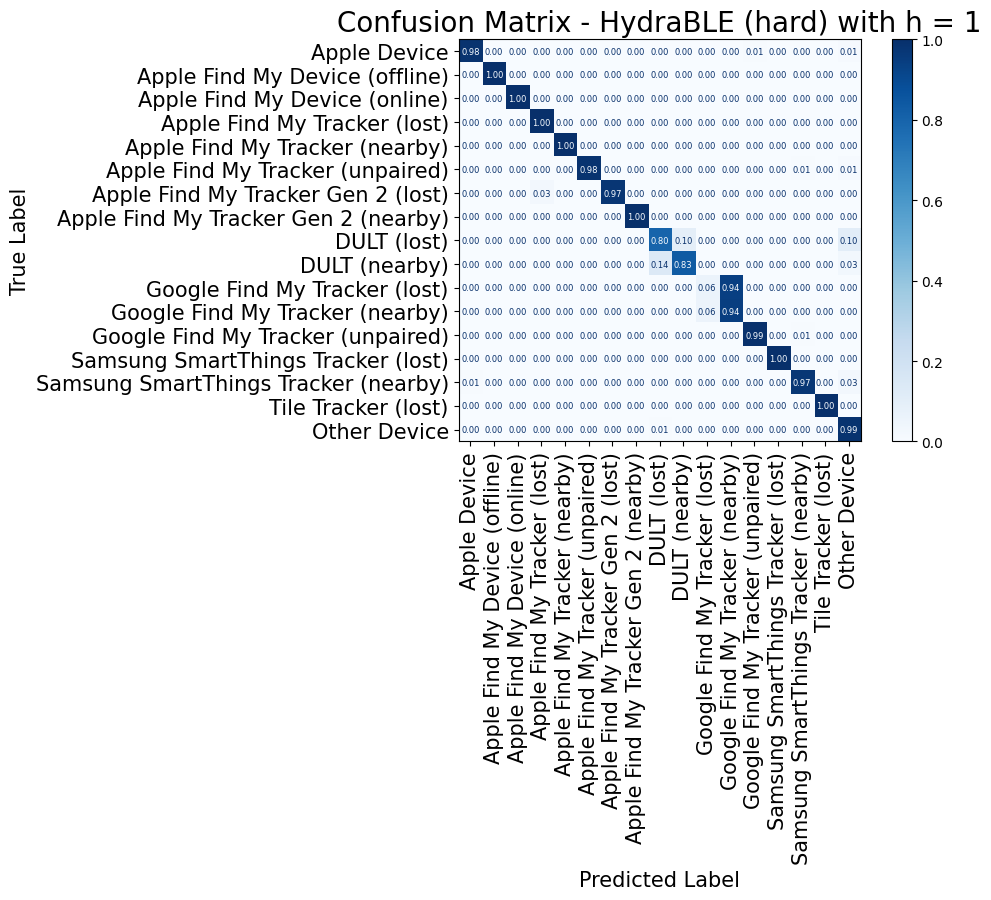

Classification Report - HydraBLE (hard) with h = 1
                                      precision    recall  f1-score   support

                        Apple Device     0.9949    0.9850    0.9899       200
      Apple Find My Device (offline)     1.0000    1.0000    1.0000       200
       Apple Find My Device (online)     1.0000    1.0000    1.0000       200
        Apple Find My Tracker (lost)     0.9569    1.0000    0.9780       200
      Apple Find My Tracker (nearby)     1.0000    1.0000    1.0000       200
    Apple Find My Tracker (unpaired)     1.0000    0.9850    0.9924       200
  Apple Find My Tracker Gen 2 (lost)     1.0000    0.9750    0.9873       200
Apple Find My Tracker Gen 2 (nearby)     1.0000    1.0000    1.0000       200
                         DULT (lost)     0.7729    0.8000    0.7862       200
                       DULT (nearby)     0.8608    0.8350    0.8477       200
       Google Find My Tracker (lost)     0.5217    0.0600    0.1076       200
     Google 

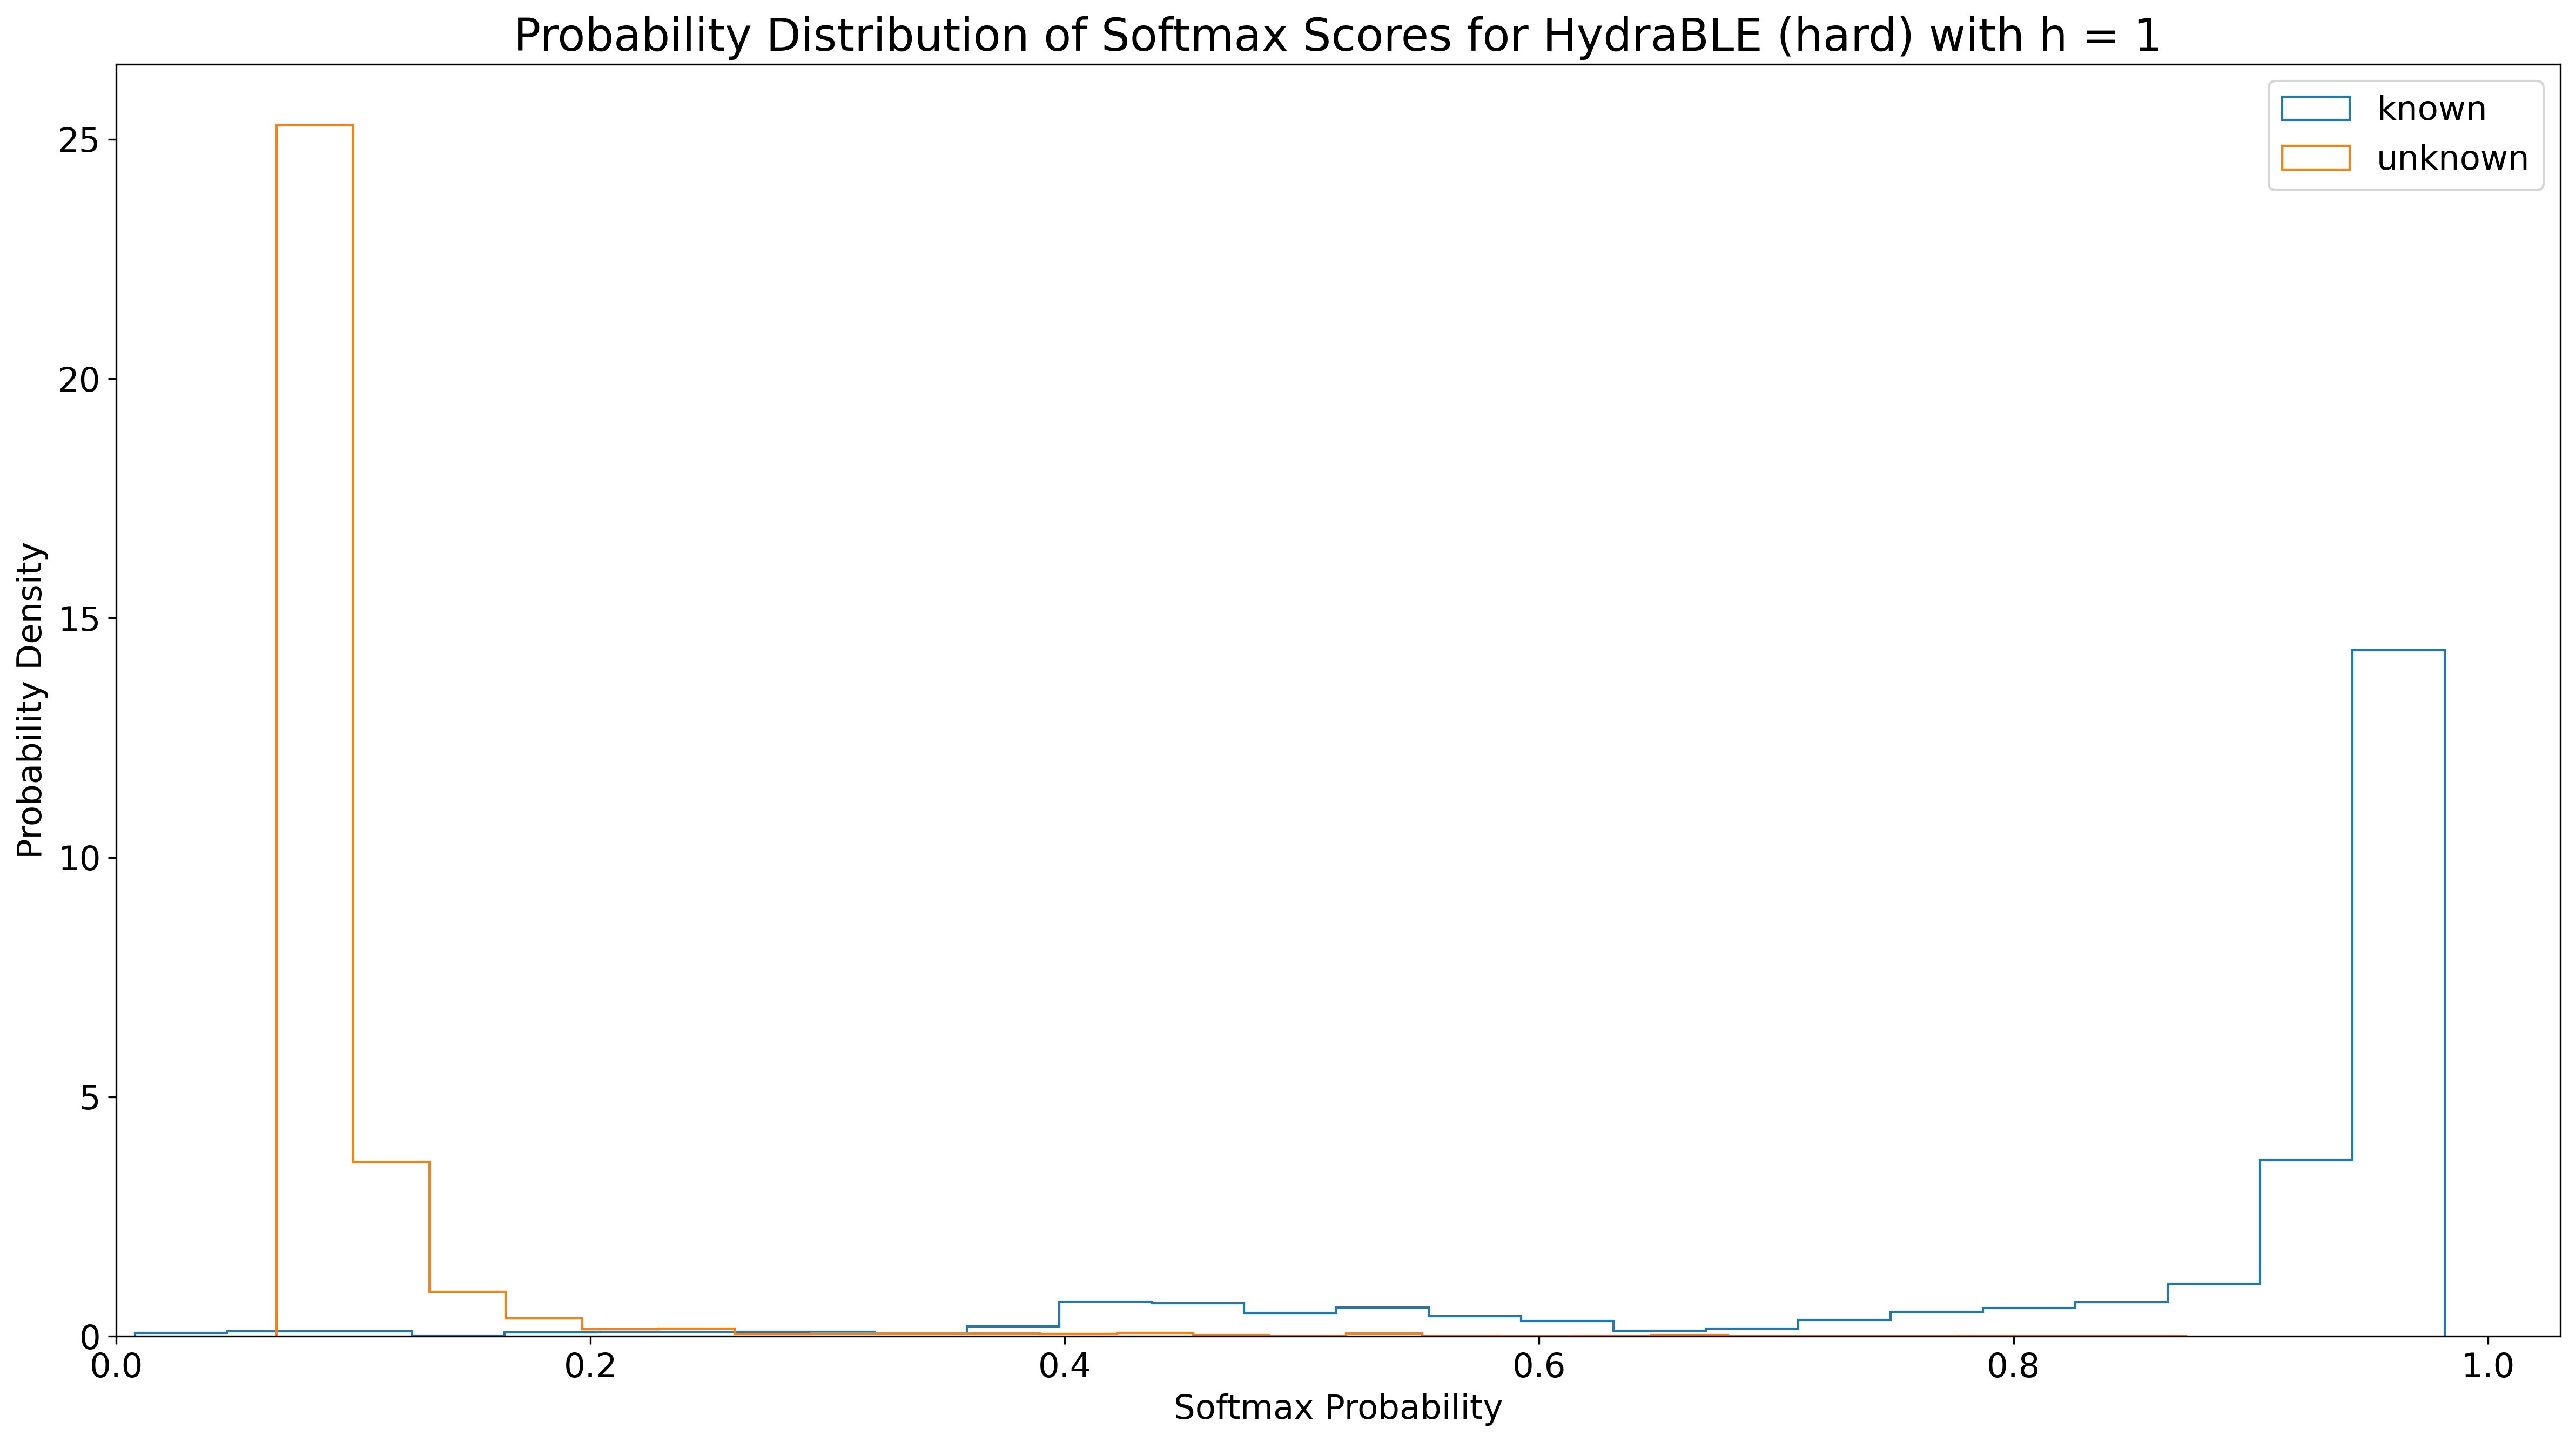

OSCR Curve started computing...
OSCR Curve finished computing in 0.04 minutes.
Accuracy Open Set (macro) started computing...
Accuracy Open Set (macro) finished computing in 0.18 minutes.
Accuracy Open Set (micro) started computing...
Accuracy Open Set (micro) finished computing in 0.17 minutes.
Accuracy Open Set (binary) started computing...
Accuracy Open Set (binary) finished computing in 0.18 minutes.


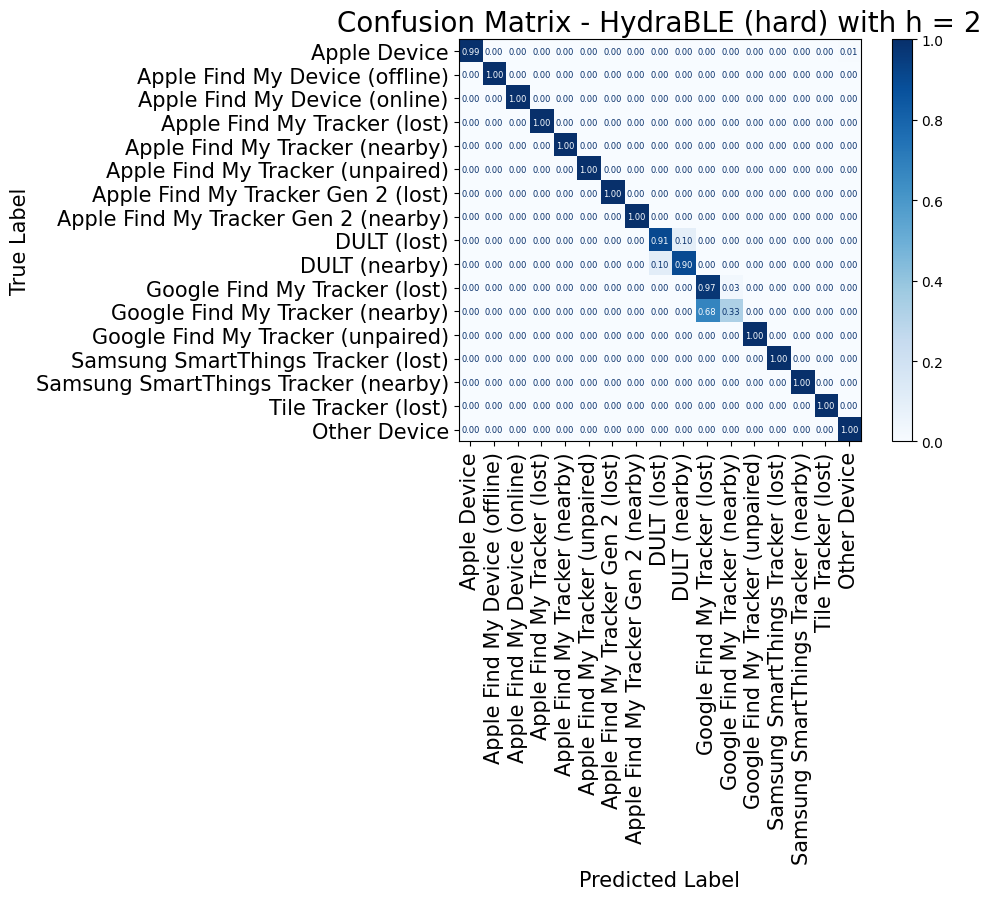

Classification Report - HydraBLE (hard) with h = 2
                                      precision    recall  f1-score   support

                        Apple Device     1.0000    0.9950    0.9975       200
      Apple Find My Device (offline)     1.0000    1.0000    1.0000       200
       Apple Find My Device (online)     1.0000    1.0000    1.0000       200
        Apple Find My Tracker (lost)     0.9950    1.0000    0.9975       200
      Apple Find My Tracker (nearby)     1.0000    1.0000    1.0000       200
    Apple Find My Tracker (unpaired)     1.0000    1.0000    1.0000       200
  Apple Find My Tracker Gen 2 (lost)     1.0000    1.0000    1.0000       200
Apple Find My Tracker Gen 2 (nearby)     1.0000    1.0000    1.0000       200
                         DULT (lost)     0.8873    0.9050    0.8960       200
                       DULT (nearby)     0.9040    0.8950    0.8995       200
       Google Find My Tracker (lost)     0.5897    0.9700    0.7335       200
     Google 

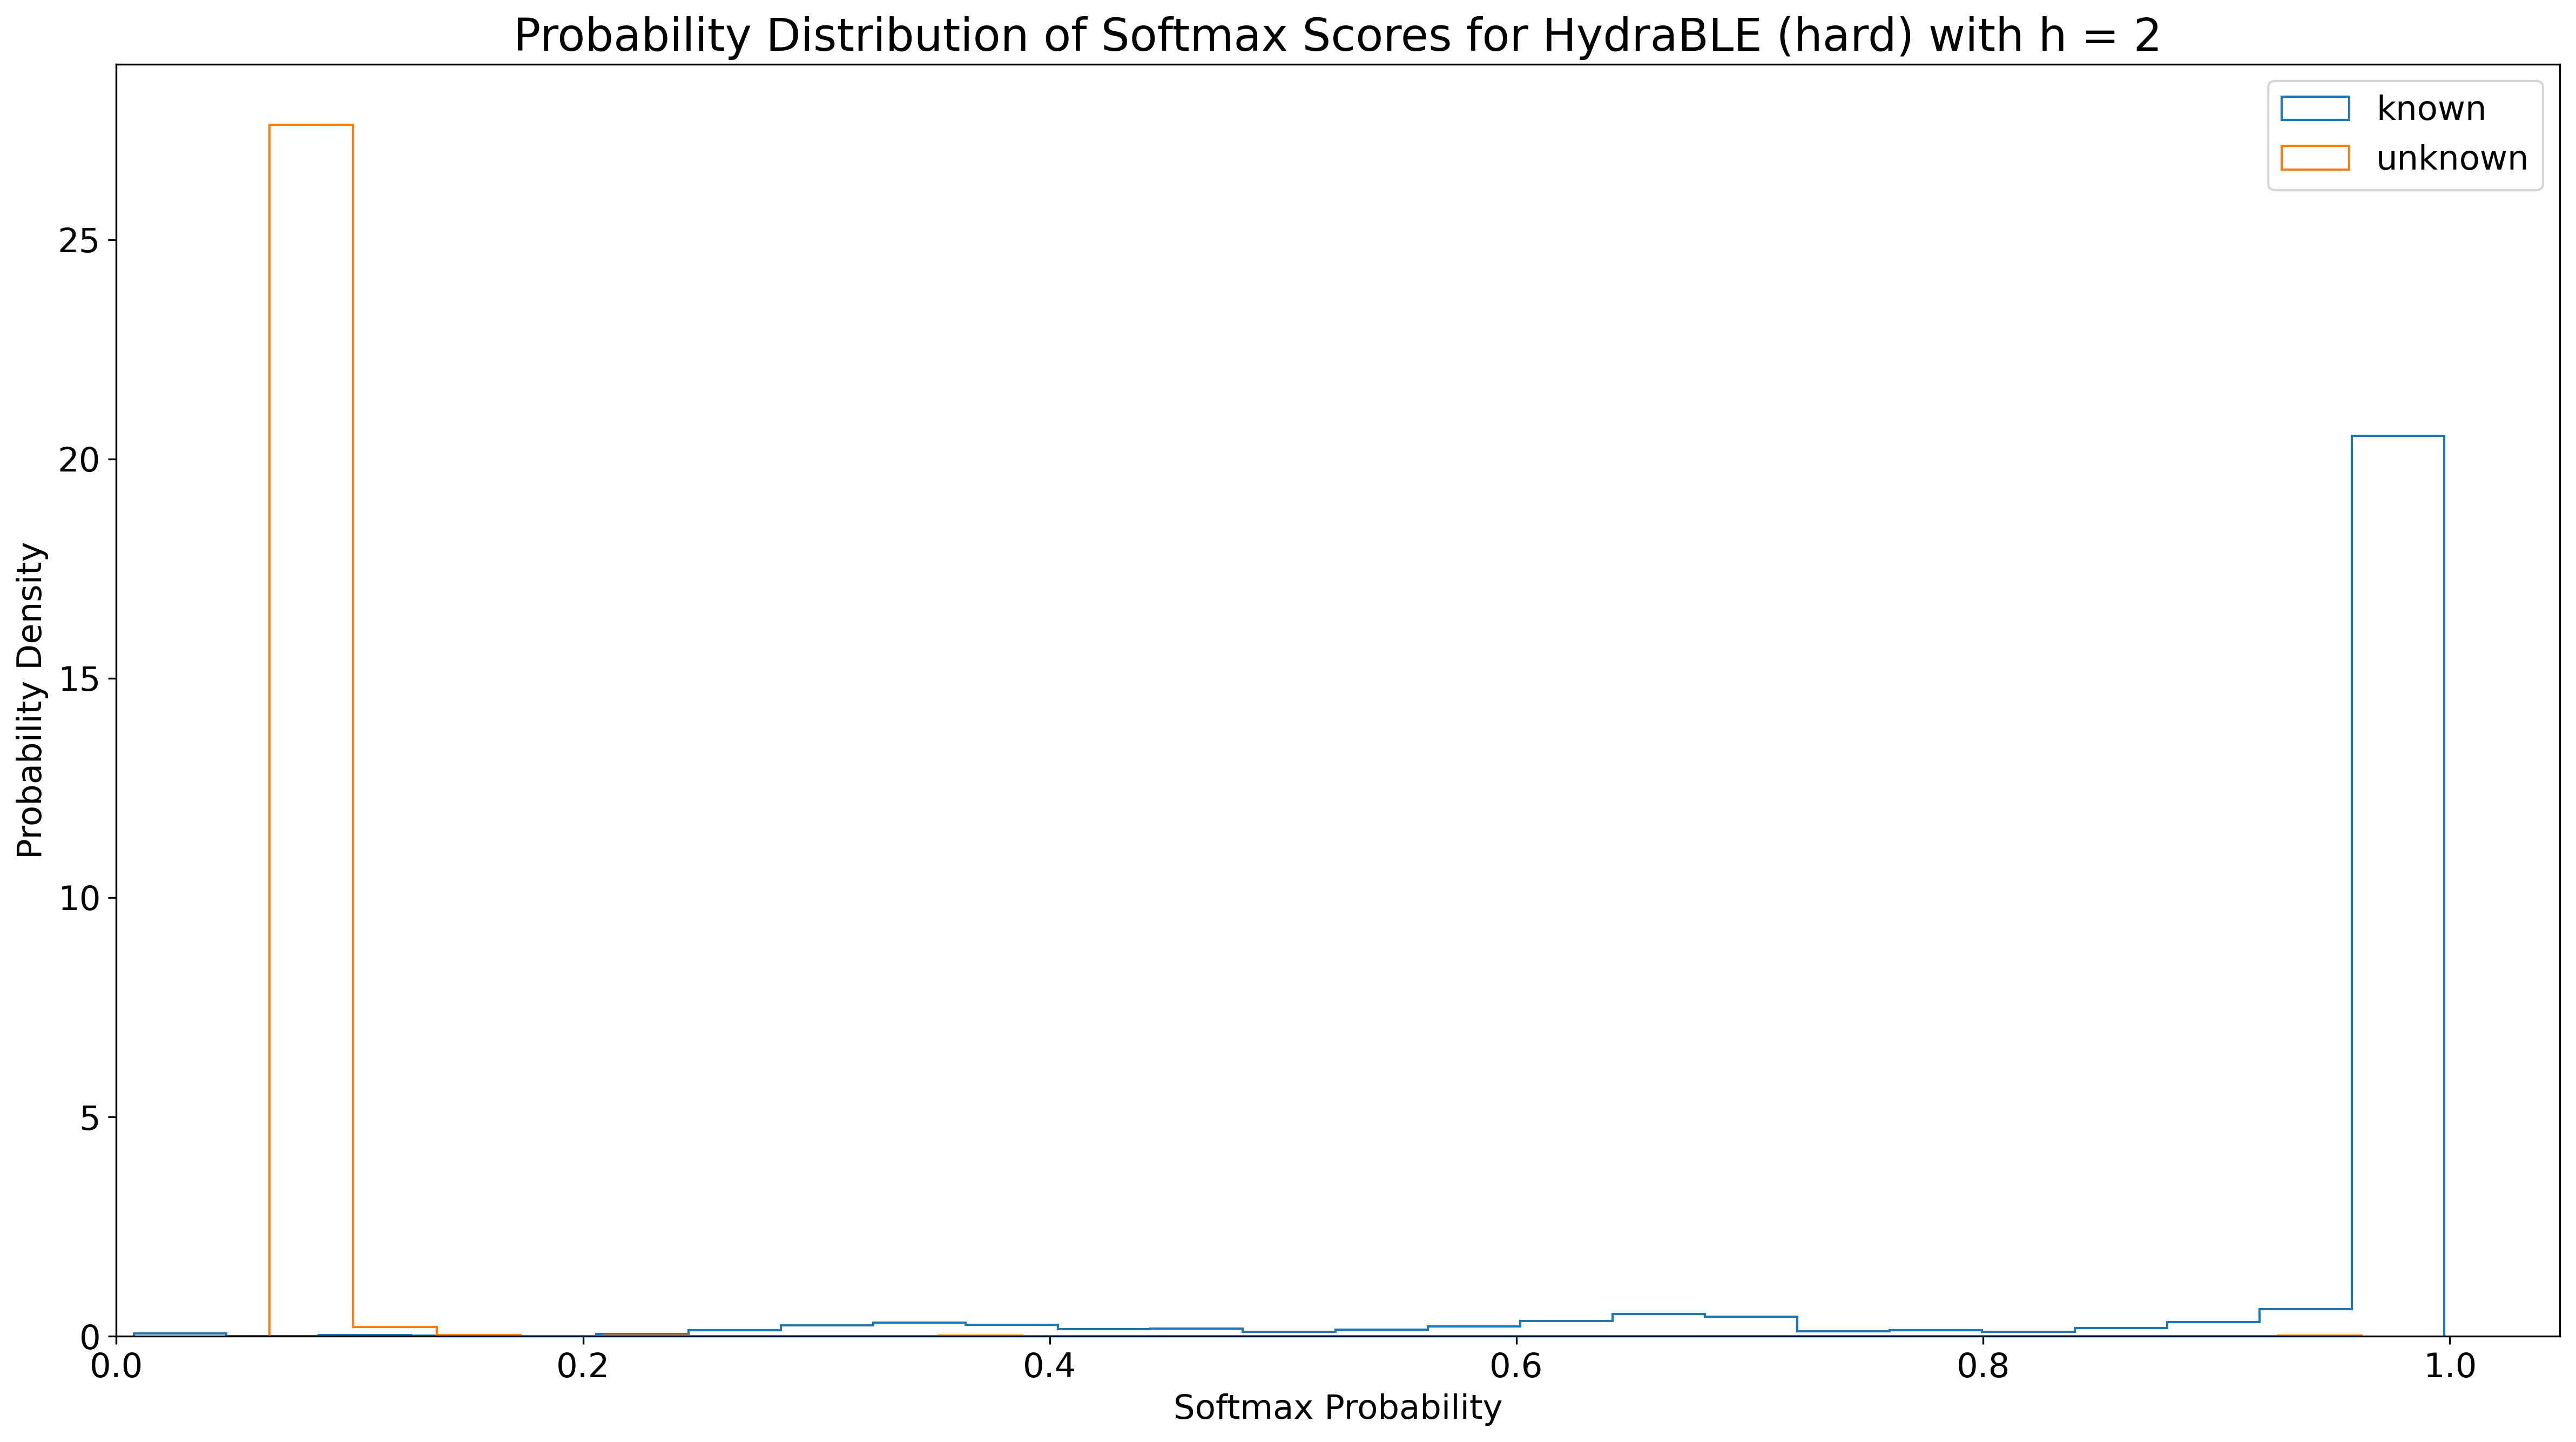

OSCR Curve started computing...
OSCR Curve finished computing in 0.04 minutes.
Accuracy Open Set (macro) started computing...
Accuracy Open Set (macro) finished computing in 0.17 minutes.
Accuracy Open Set (micro) started computing...
Accuracy Open Set (micro) finished computing in 0.18 minutes.
Accuracy Open Set (binary) started computing...
Accuracy Open Set (binary) finished computing in 0.17 minutes.


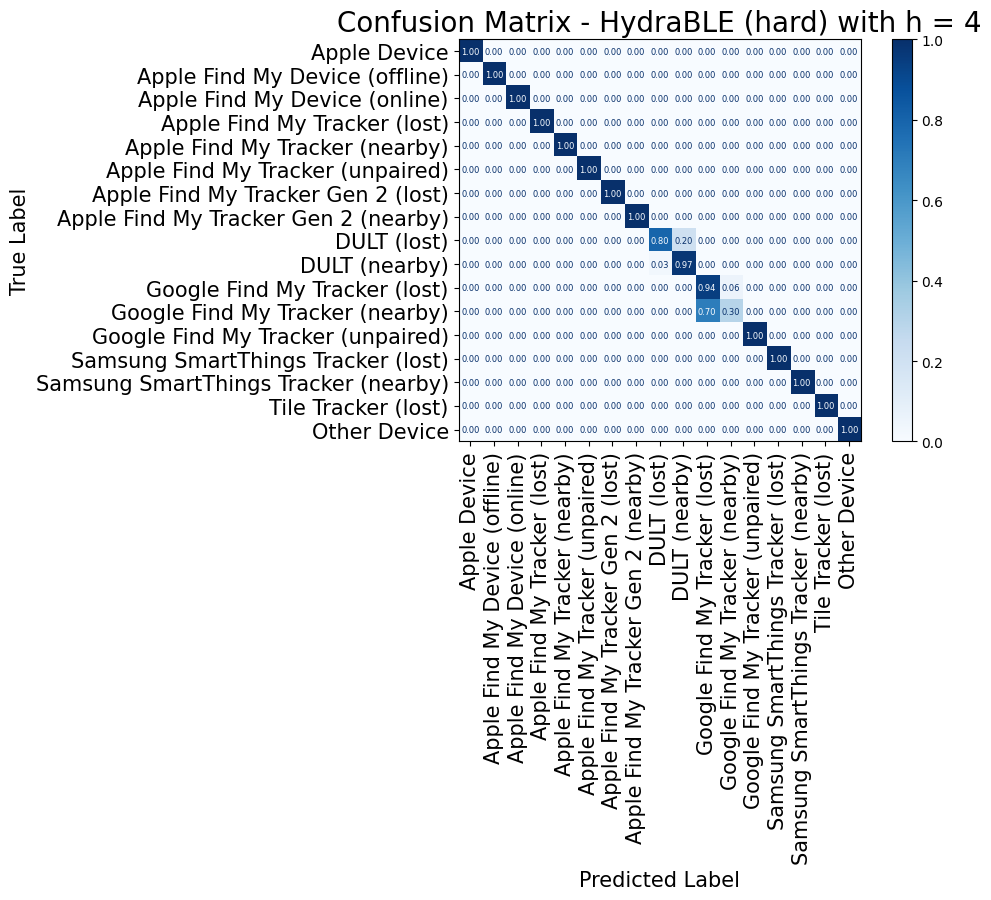

Classification Report - HydraBLE (hard) with h = 4
                                      precision    recall  f1-score   support

                        Apple Device     1.0000    1.0000    1.0000       200
      Apple Find My Device (offline)     1.0000    1.0000    1.0000       200
       Apple Find My Device (online)     1.0000    1.0000    1.0000       200
        Apple Find My Tracker (lost)     1.0000    1.0000    1.0000       200
      Apple Find My Tracker (nearby)     1.0000    1.0000    1.0000       200
    Apple Find My Tracker (unpaired)     1.0000    1.0000    1.0000       200
  Apple Find My Tracker Gen 2 (lost)     1.0000    1.0000    1.0000       200
Apple Find My Tracker Gen 2 (nearby)     1.0000    1.0000    1.0000       200
                         DULT (lost)     0.9578    0.7950    0.8689       200
                       DULT (nearby)     0.8220    0.9700    0.8899       200
       Google Find My Tracker (lost)     0.5745    0.9450    0.7146       200
     Google 

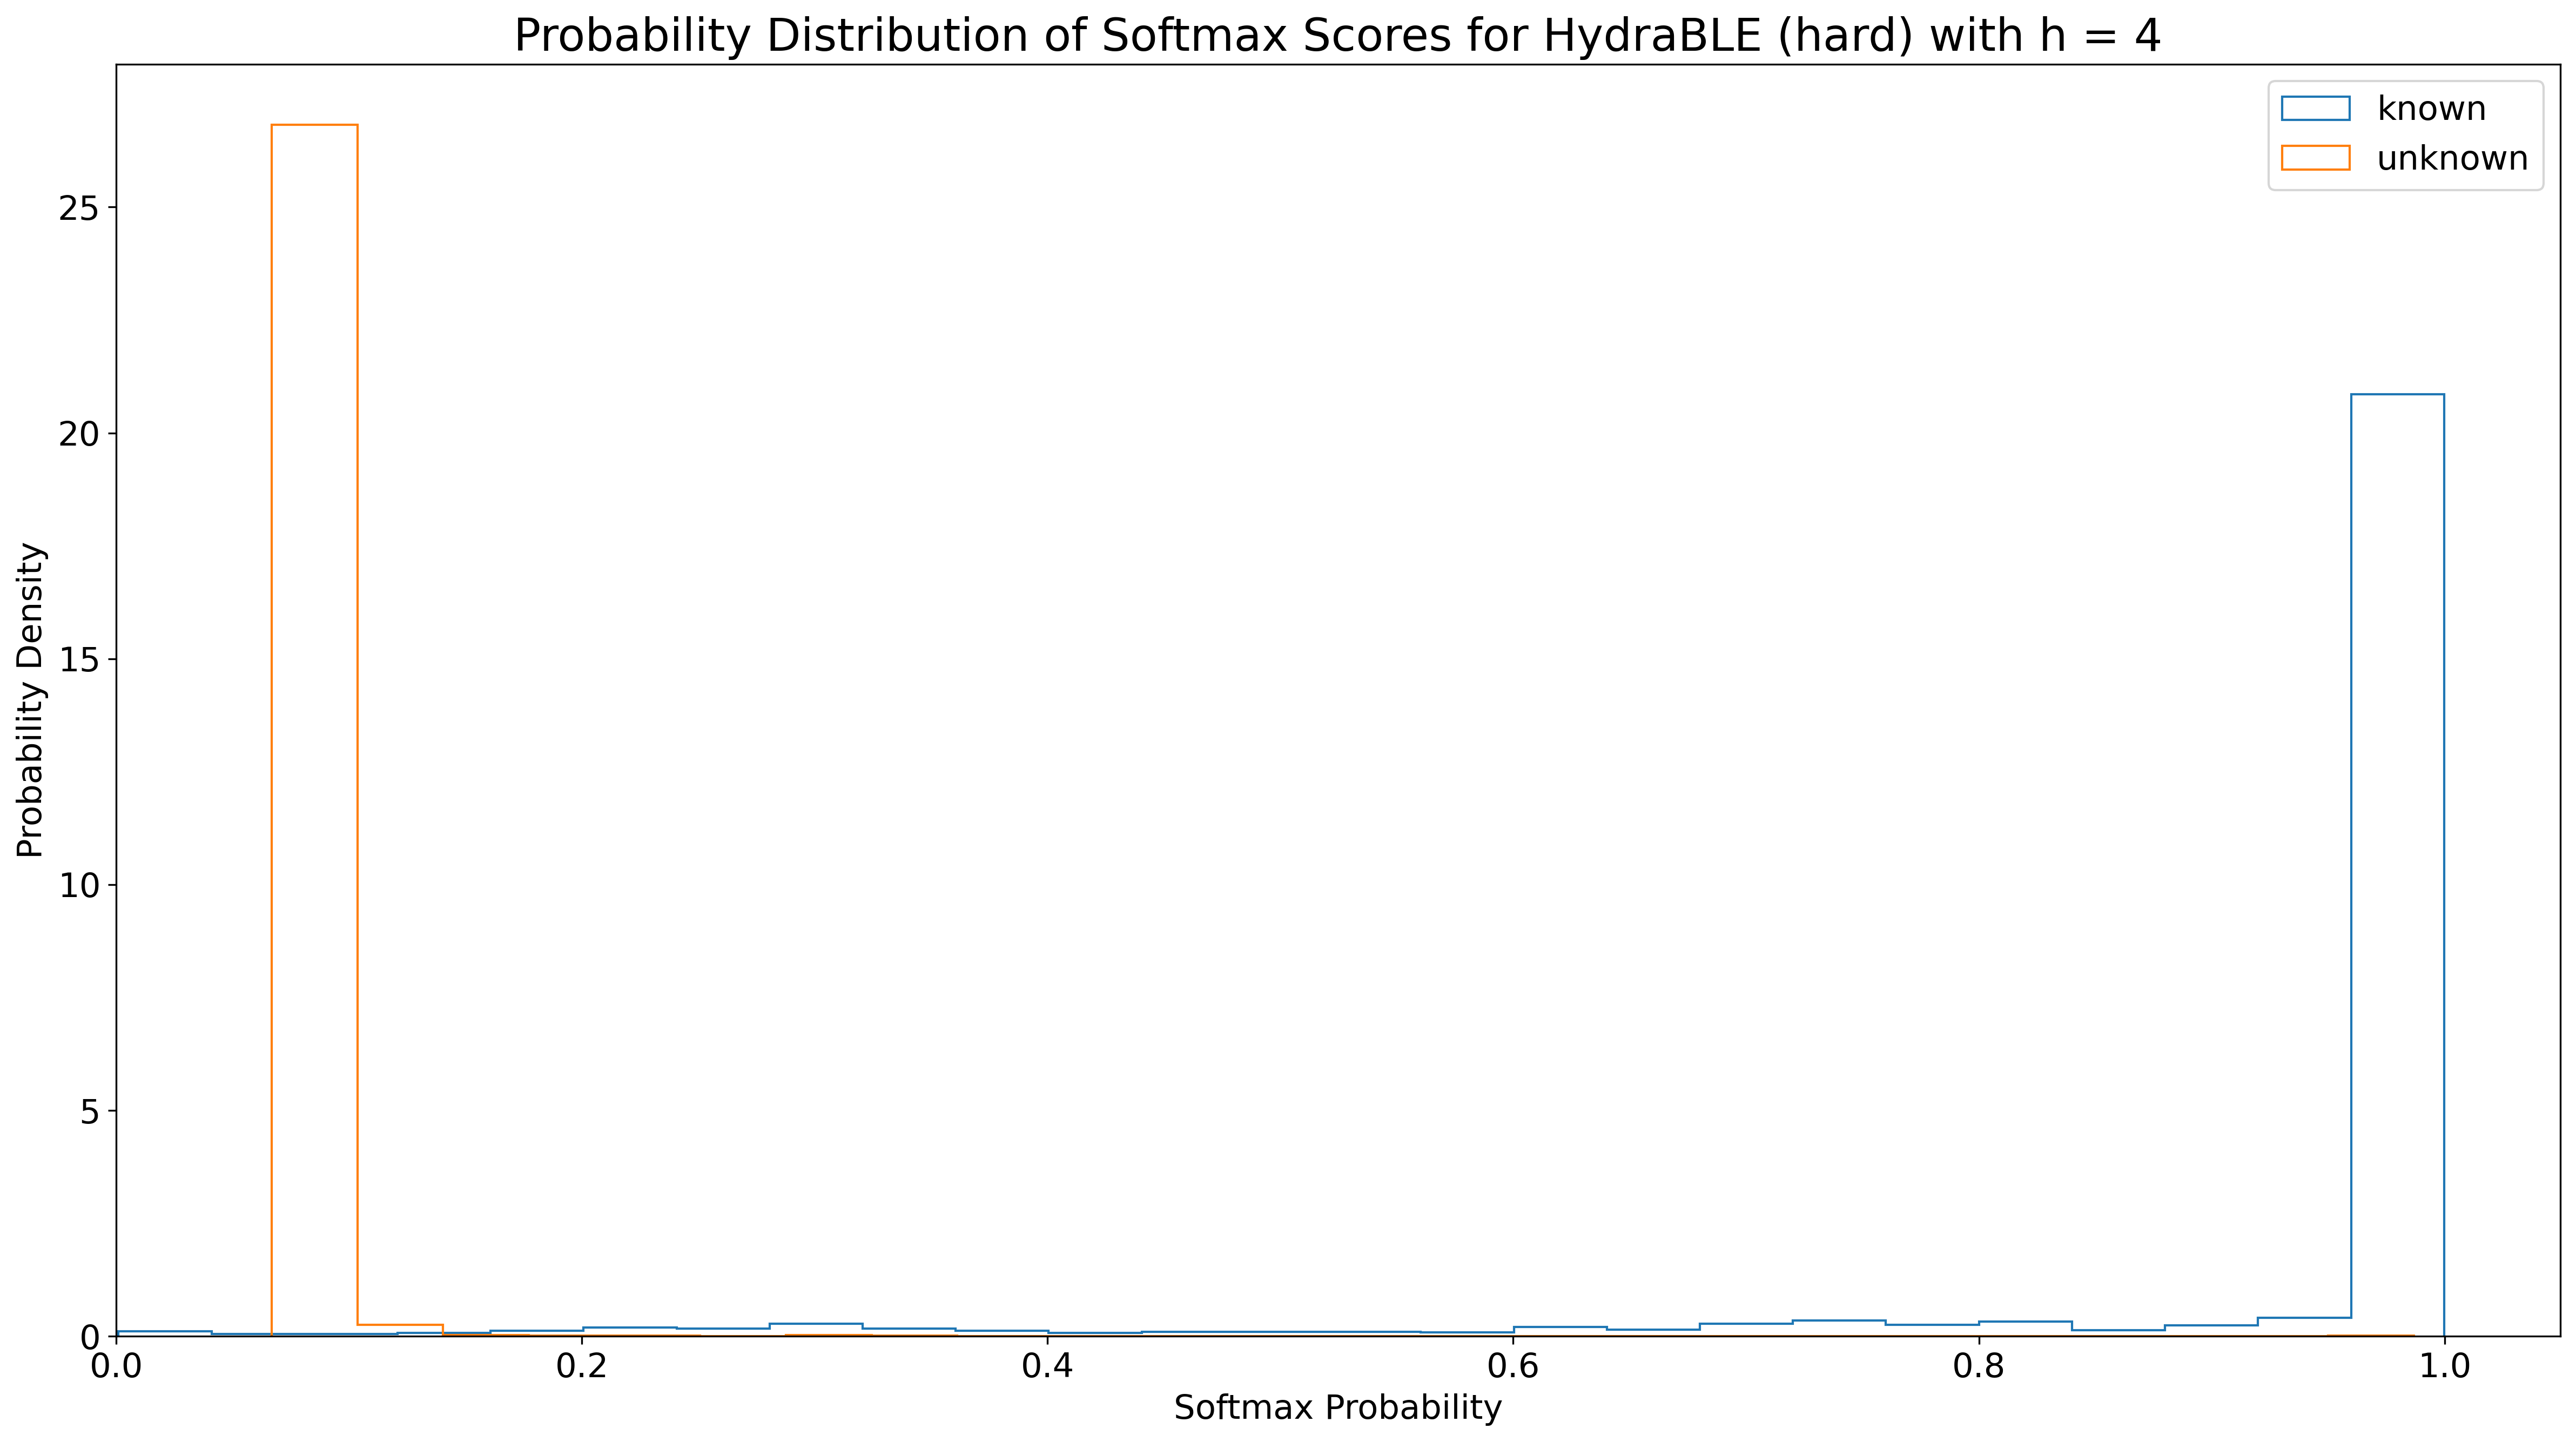

OSCR Curve started computing...
OSCR Curve finished computing in 0.04 minutes.
Accuracy Open Set (macro) started computing...
Accuracy Open Set (macro) finished computing in 0.17 minutes.
Accuracy Open Set (micro) started computing...
Accuracy Open Set (micro) finished computing in 0.16 minutes.
Accuracy Open Set (binary) started computing...
Accuracy Open Set (binary) finished computing in 0.16 minutes.


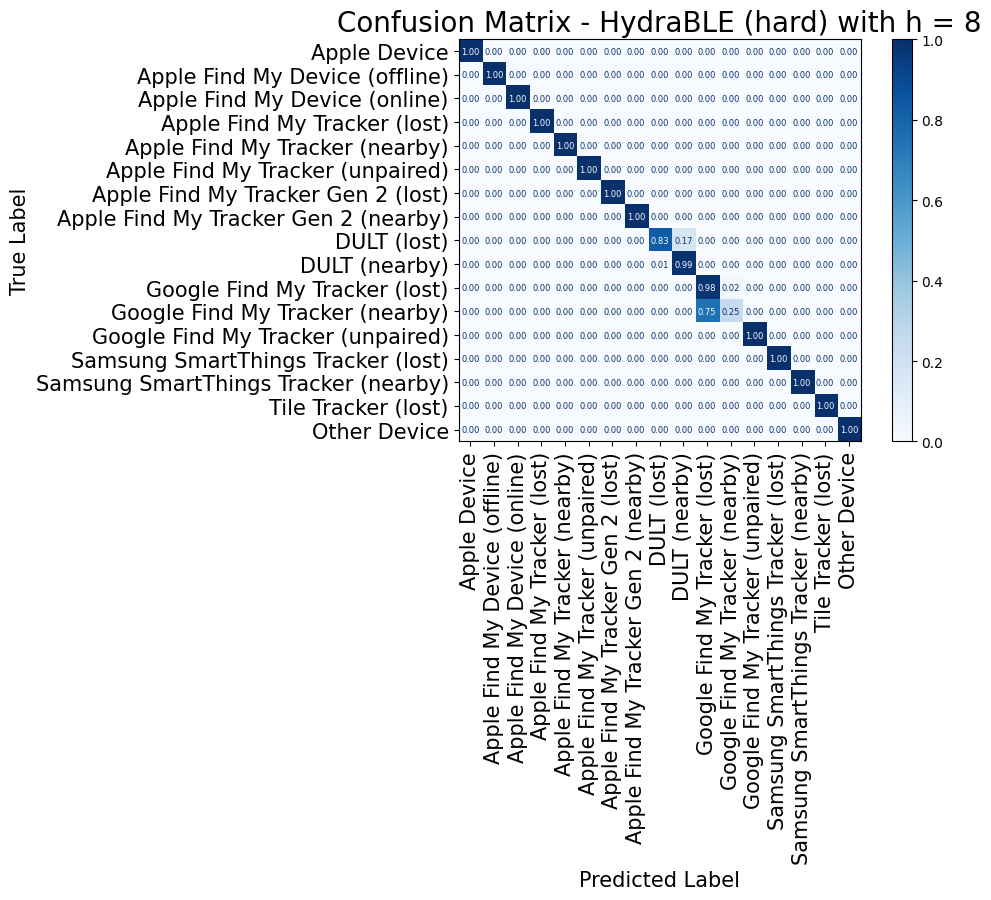

Classification Report - HydraBLE (hard) with h = 8
                                      precision    recall  f1-score   support

                        Apple Device     1.0000    1.0000    1.0000       200
      Apple Find My Device (offline)     1.0000    1.0000    1.0000       200
       Apple Find My Device (online)     0.9950    1.0000    0.9975       200
        Apple Find My Tracker (lost)     1.0000    1.0000    1.0000       200
      Apple Find My Tracker (nearby)     1.0000    1.0000    1.0000       200
    Apple Find My Tracker (unpaired)     1.0000    1.0000    1.0000       200
  Apple Find My Tracker Gen 2 (lost)     1.0000    1.0000    1.0000       200
Apple Find My Tracker Gen 2 (nearby)     0.9950    1.0000    0.9975       200
                         DULT (lost)     0.9765    0.8300    0.8973       200
                       DULT (nearby)     0.8534    0.9900    0.9167       200
       Google Find My Tracker (lost)     0.5665    0.9800    0.7179       200
     Google 

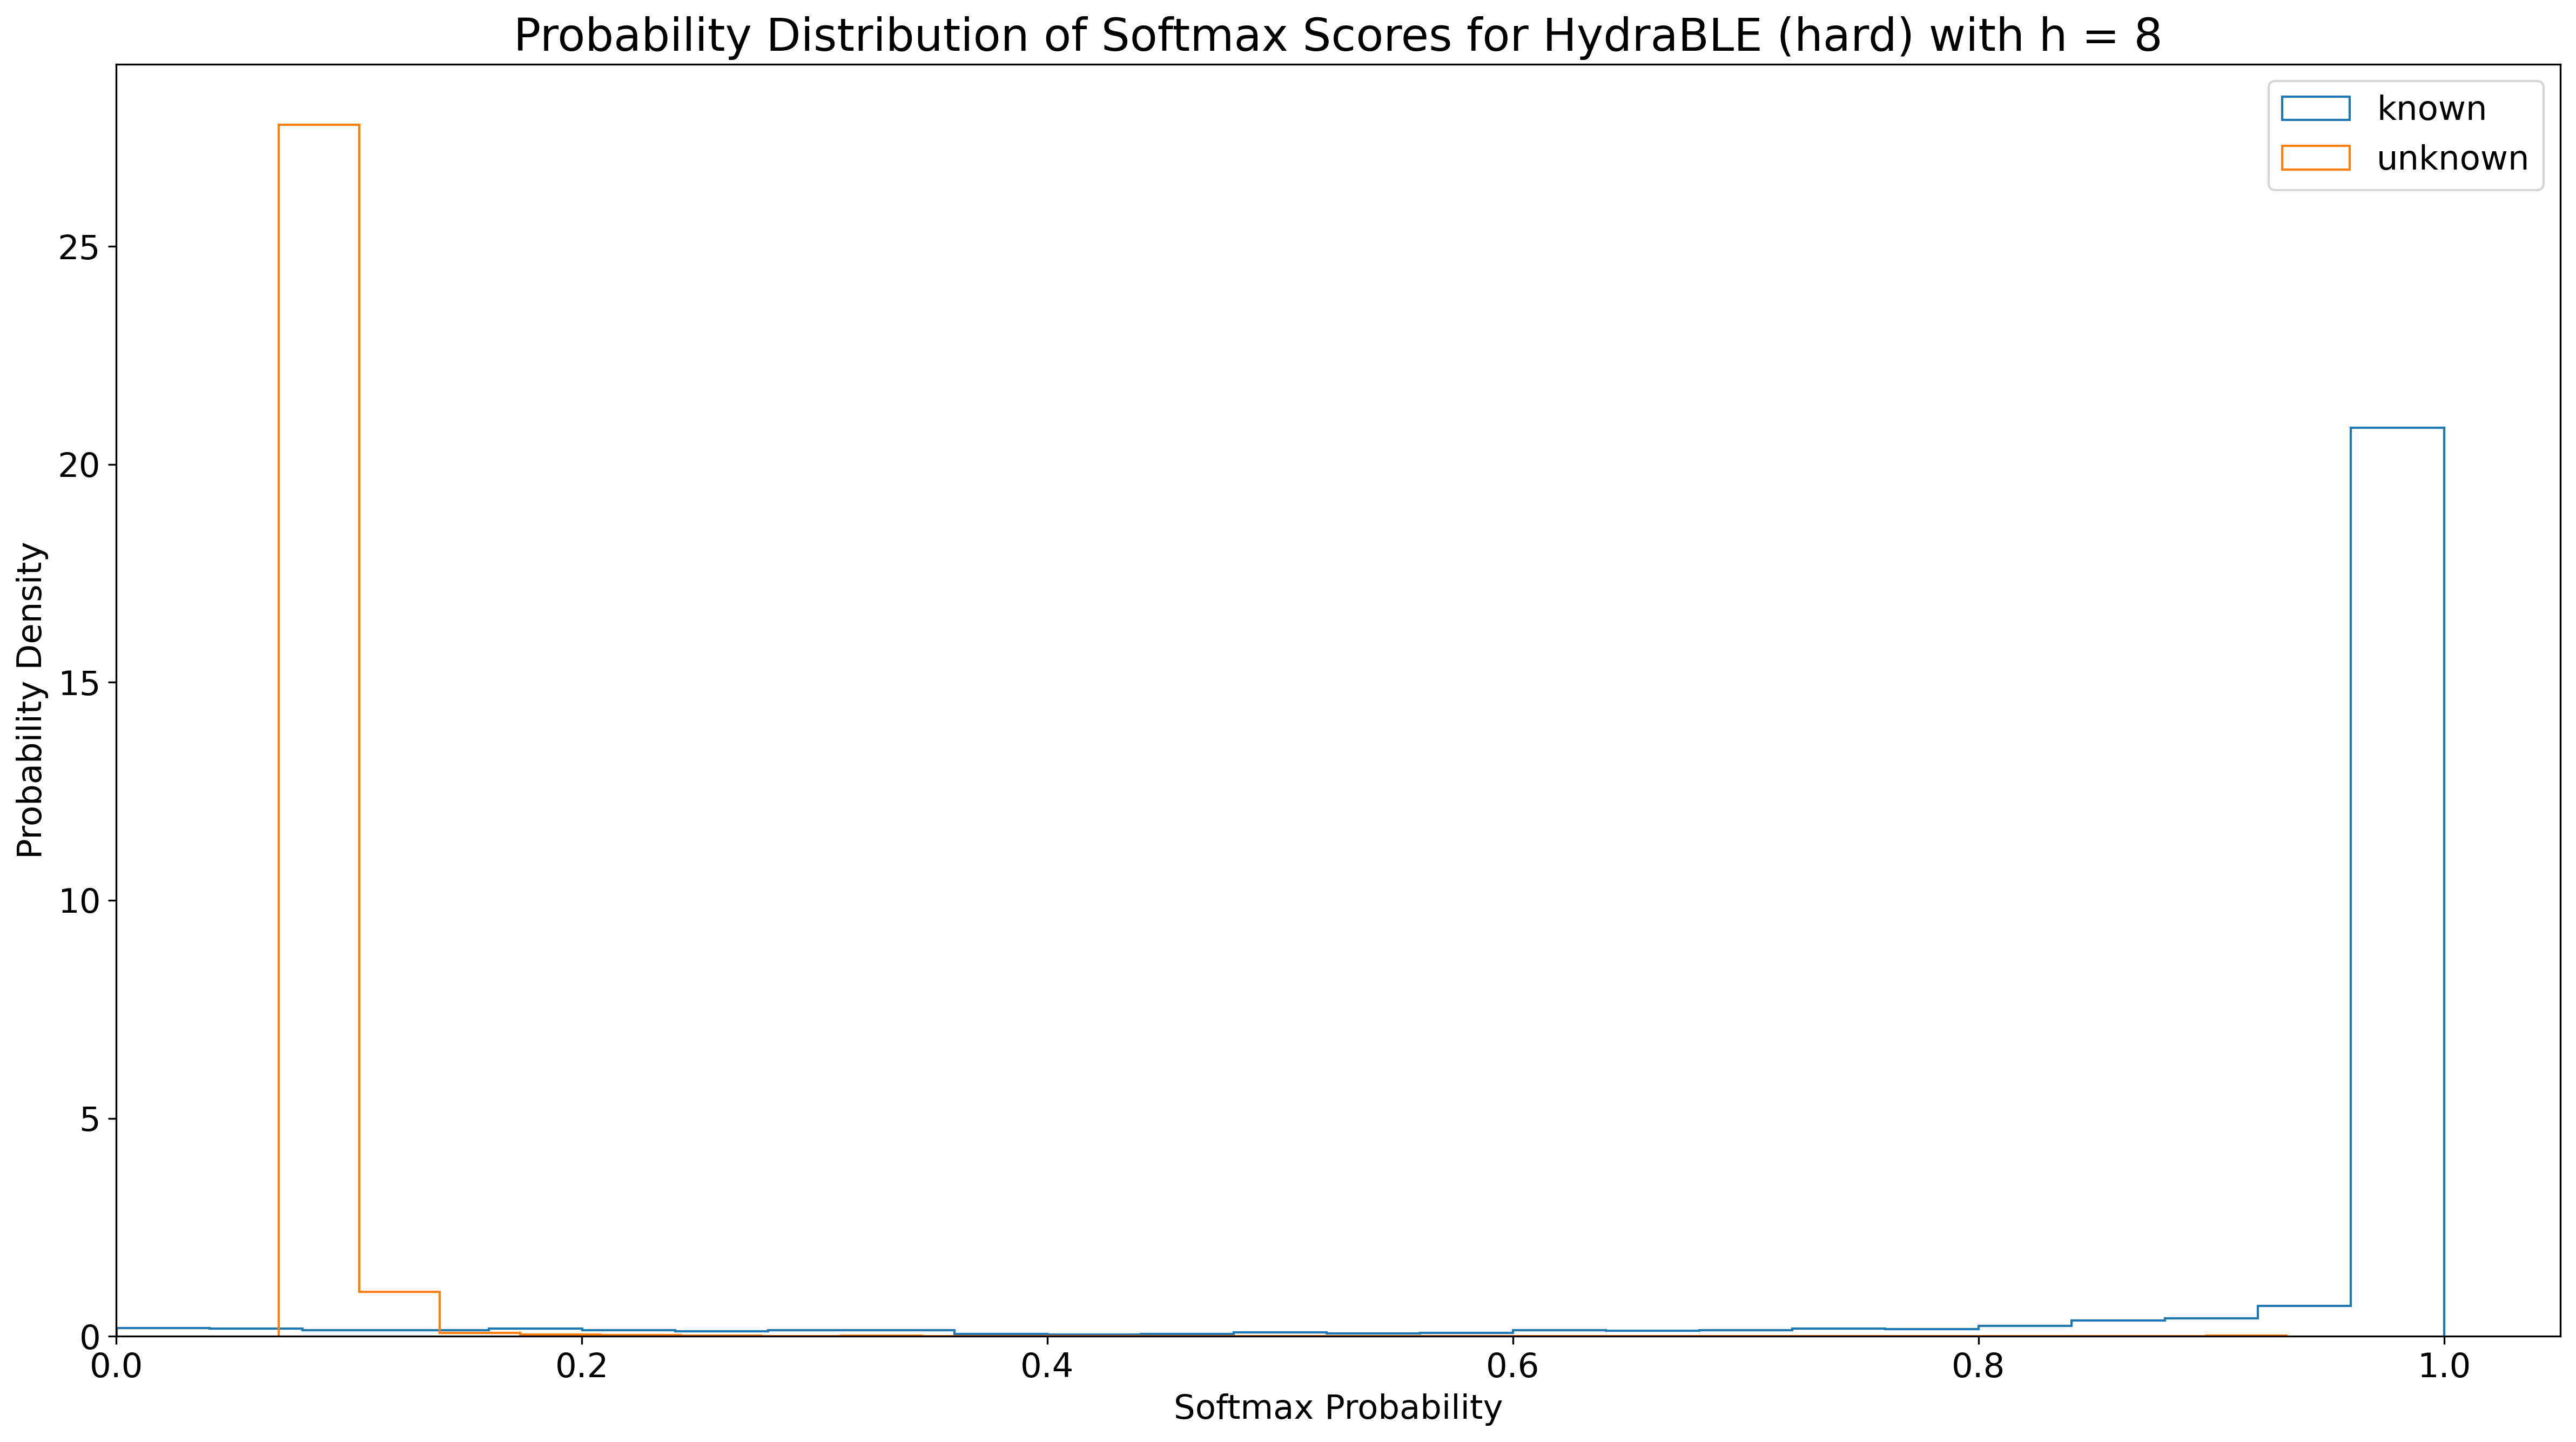

In [6]:
from plotting.src.functions import plotMatrix, FONTSIZE_LABEL, FONTSIZE_TICKS, FONTSIZE_TITLE, plotReport
import matplotlib.pyplot as plt
plt.style.use('default')

oscr_lut = dict()
acc_micro_lut = dict()
acc_macro_lut = dict()
acc_binary_lut = dict()

metric_table = [['Accuracy (micro)', 'Accuracy (macro)', 'Accuracy (binary)', 'CCR at FPR = 1e-1', 'CCR at FPR = 1e-2','CCR at FPR = 1e-3']]

for h in H_VALS:
    logits = torch.load(logitsPath + f"logits_classification_h={h}_hard_test.pt")
    targets  = torch.load(logitsPath + f"label_ids_classification_h={h}_hard_test.pt")

    exp = Experiment(name="Test-Experiment")
    exp.configure(config)
    exp.add_data(logits=logits, targets=targets)

    score = exp.score()

    threshold = thresholds[h]
    threshold_idx = threshold_indexes[h]

    probas = torch.nn.functional.softmax(logits, dim = 1)
    max_probas, pred_classes = probas.max(dim=1)

    predictions = torch.where(max_probas >= threshold, pred_classes, torch.full_like(pred_classes, label_id_unknown))

    predictions_text = [label_lut[int(i)] for i in predictions]
    targets_text = [label_lut[int(i)] for i in targets]

    plotMatrix(targets_text, predictions_text, list(label_lut.values()), name=f"HydraBLE (hard) with h = {h}", savePath=plotPath)
    plotReport(targets_text, predictions_text, list(label_lut.values()), name=f"HydraBLE (hard) with h = {h}", savePath=tablePath)

    oscr_lut[h] = score['OSCR Curve']
    acc_micro_lut[h] = score['Accuracy Open Set (micro)']
    acc_macro_lut[h] = score['Accuracy Open Set (macro)']
    acc_binary_lut[h] = score['Accuracy Open Set (binary)']


    fprs = oscr_lut[h][:, 0]
    ccrs = oscr_lut[h][:, 1]

    fpr_01_idx = torch.argmin(torch.abs(0.1 - fprs))
    fpr_001_idx = torch.argmin(torch.abs(0.01 - fprs))
    fpr_0001_idx = torch.argmin(torch.abs(0.001 - fprs))

    metric_table.append([float(acc_micro_lut[h][threshold_idx]),
                         float(acc_macro_lut[h][threshold_idx]),
                         float(acc_binary_lut[h][threshold_idx]),
                         float(ccrs[fpr_01_idx]),
                         float(ccrs[fpr_001_idx]),
                         float(ccrs[fpr_0001_idx])
                         ])


    probas = torch.nn.functional.softmax(logits, dim = 1)

    mask_known = (targets != label_id_unknown)
    mask_unknown = (targets == label_id_unknown)

    probas_known = probas[mask_known]
    probas_unknown = probas[mask_unknown]


    true_probas_known = probas_known[torch.arange(len(probas_known)), targets[mask_known]]
    max_probas_unknown, _ = probas_unknown.max(dim = 1)


    plt.figure(figsize=(16, 9), dpi = 300)
    plt.hist(true_probas_known, bins = 25, density=True, histtype='step', label='known')
    plt.hist(max_probas_unknown, bins = 25, density=True, histtype='step', label='unknown')

    plt.ylabel("Probability Density", fontsize=FONTSIZE_LABEL)
    plt.xlabel("Softmax Probability", fontsize=FONTSIZE_LABEL)

    plt.xticks(fontsize=FONTSIZE_TICKS)
    plt.yticks(fontsize=FONTSIZE_TICKS)

    plt.ylim(bottom = 0)
    plt.xlim(left=0)

    title = f"Probability Distribution of Softmax Scores for HydraBLE (hard) with h = {h}"
    plt.title(title, fontsize=FONTSIZE_TITLE)
    plt.legend(fontsize=FONTSIZE_LABEL)
    plt.tight_layout()

    plt.tight_layout()
    plt.savefig(plotPath + title + ".png", dpi = 300)
    plt.show()


In [7]:
import numpy as np

def plot_curve(lut: dict, title: str, y_label: str):
    plt.style.use('default')
    thresholds_x = np.linspace(0, 1, 10**PRECISION+1)

    plt.figure(figsize=(16, 9), dpi = 300)

    for h, values in lut.items():
        plt.plot(thresholds_x, values, label=f"h = {h}")

    plt.xticks(fontsize=FONTSIZE_TICKS)
    plt.yticks(fontsize=FONTSIZE_TICKS)
    plt.xlabel("Threshold", fontsize=FONTSIZE_LABEL)
    plt.ylim(0, 1.1)
    plt.ylabel(y_label, fontsize=FONTSIZE_LABEL)
    plt.title(title, fontsize=FONTSIZE_TITLE)
    plt.legend()
    plt.tight_layout()
    plt.savefig(plotPath + title + ".png", dpi = 300)
    plt.show()


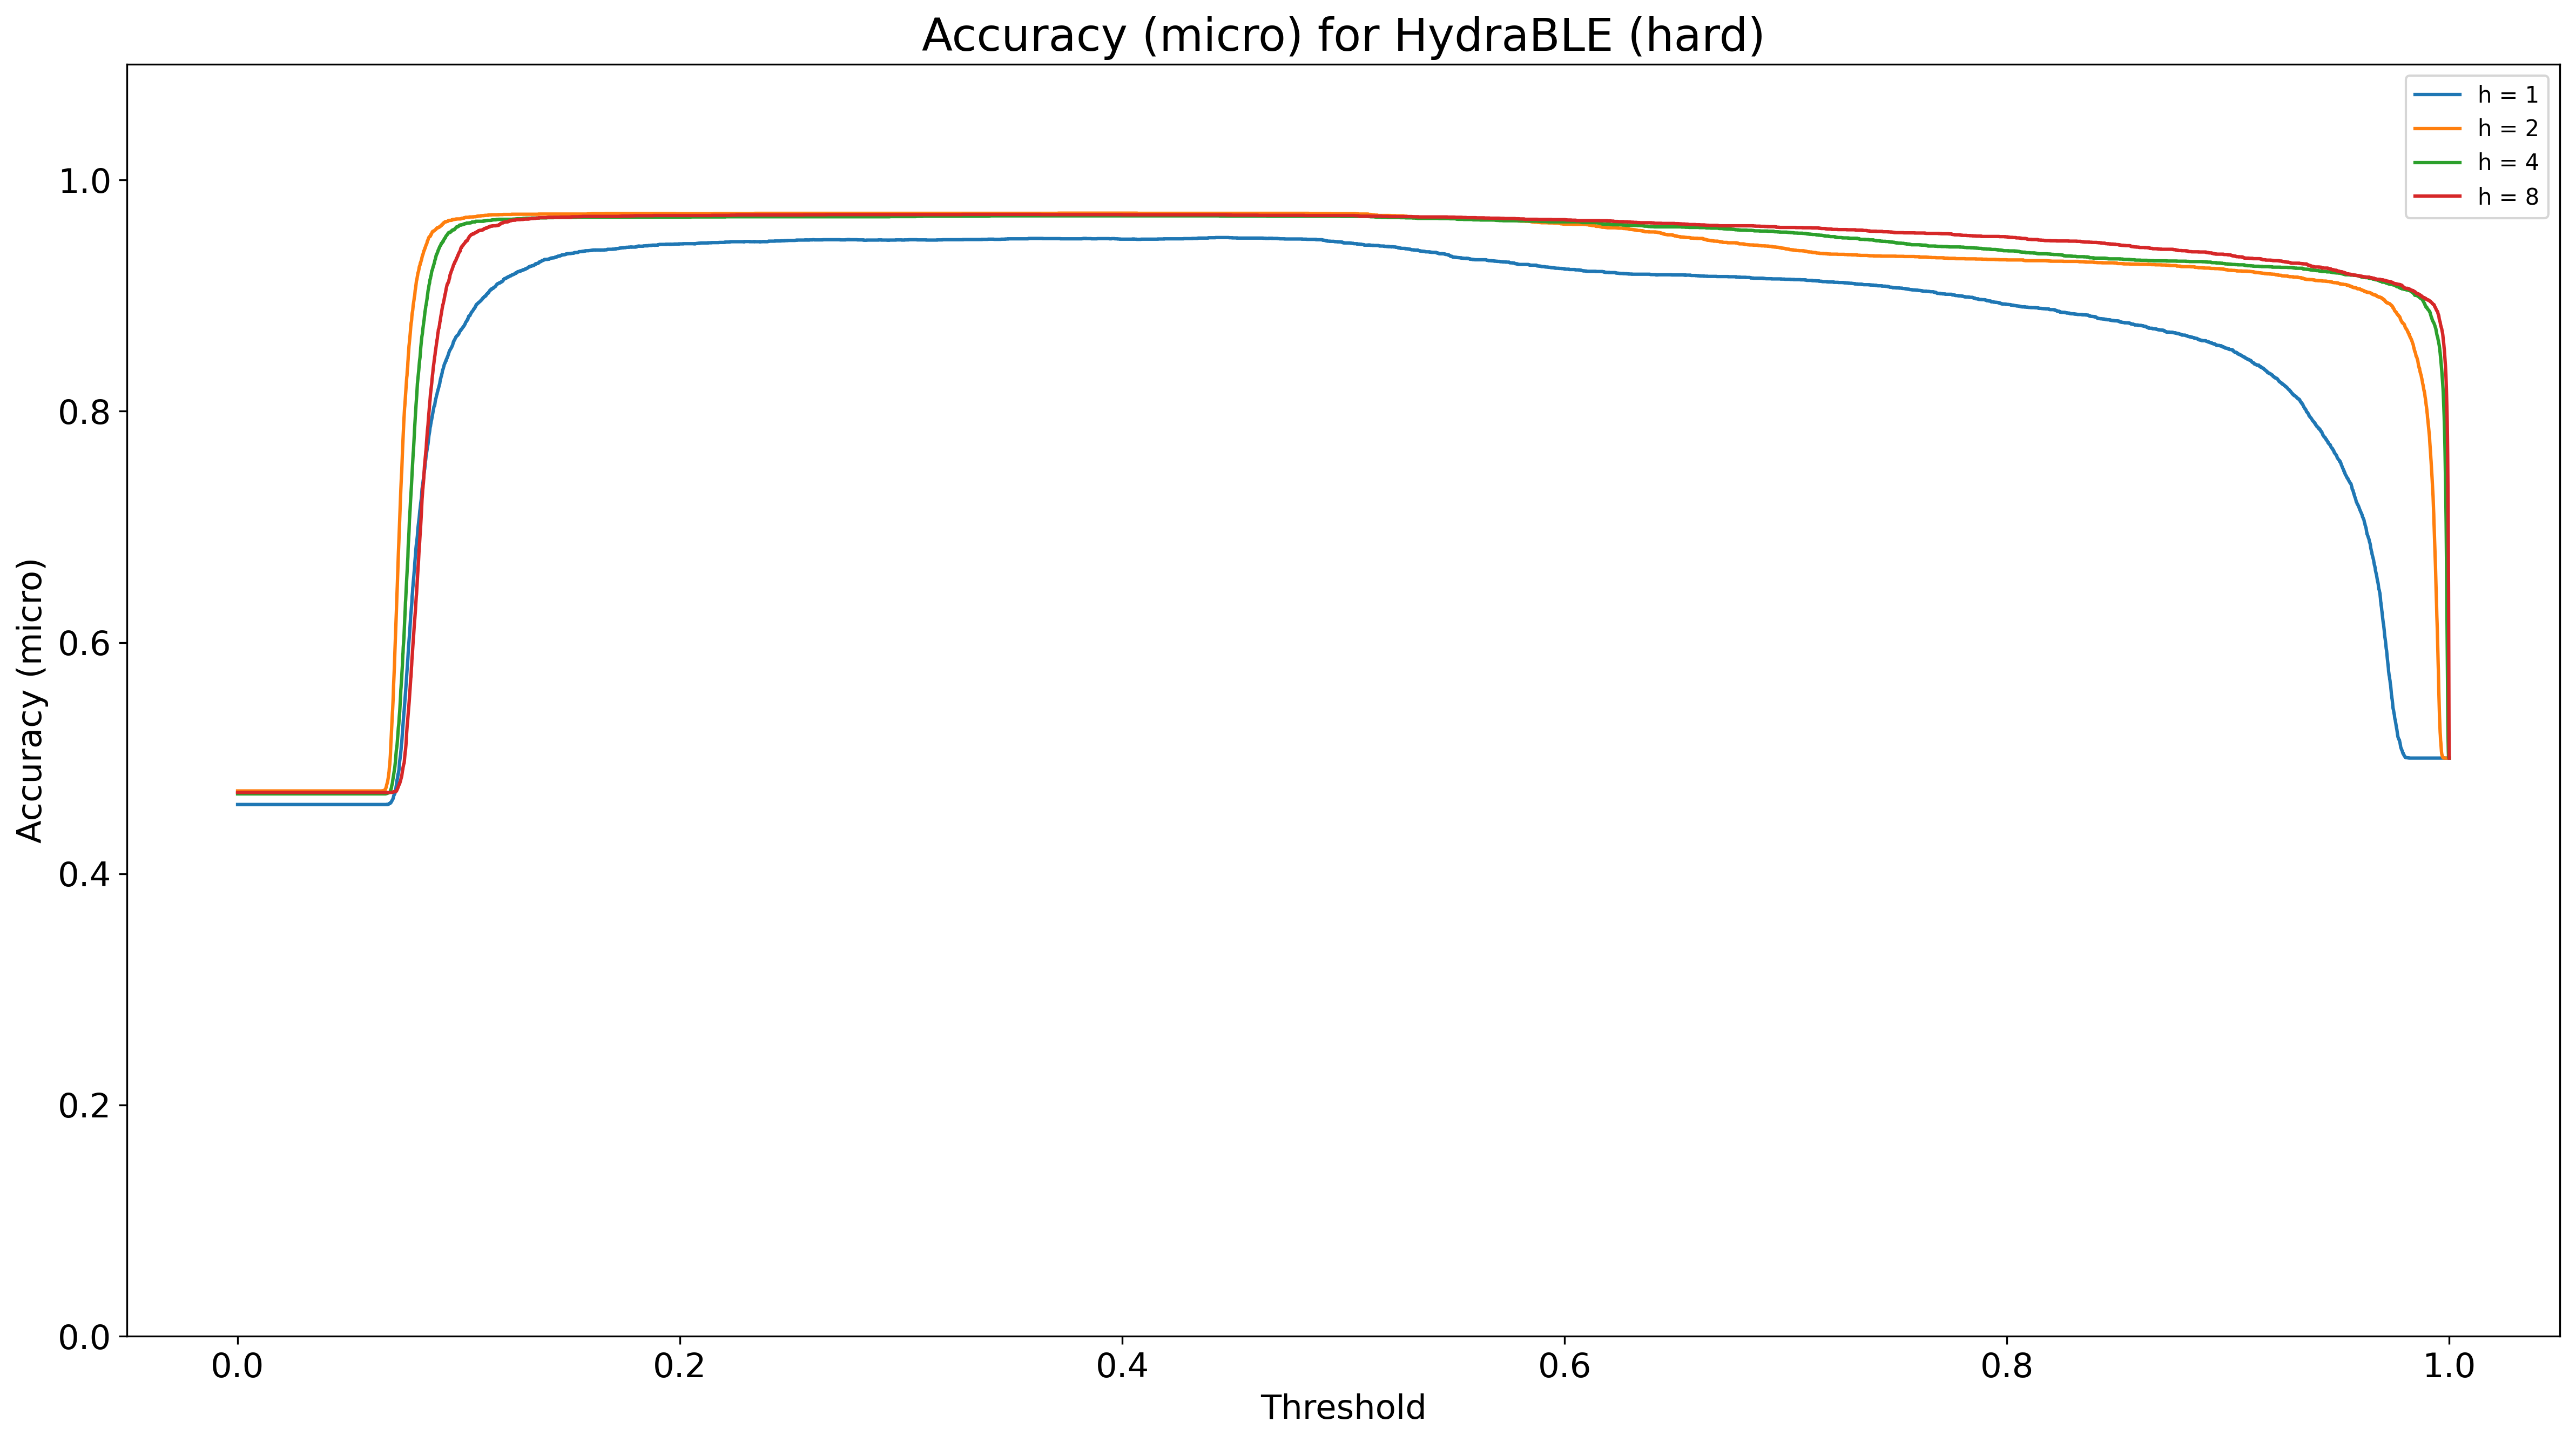

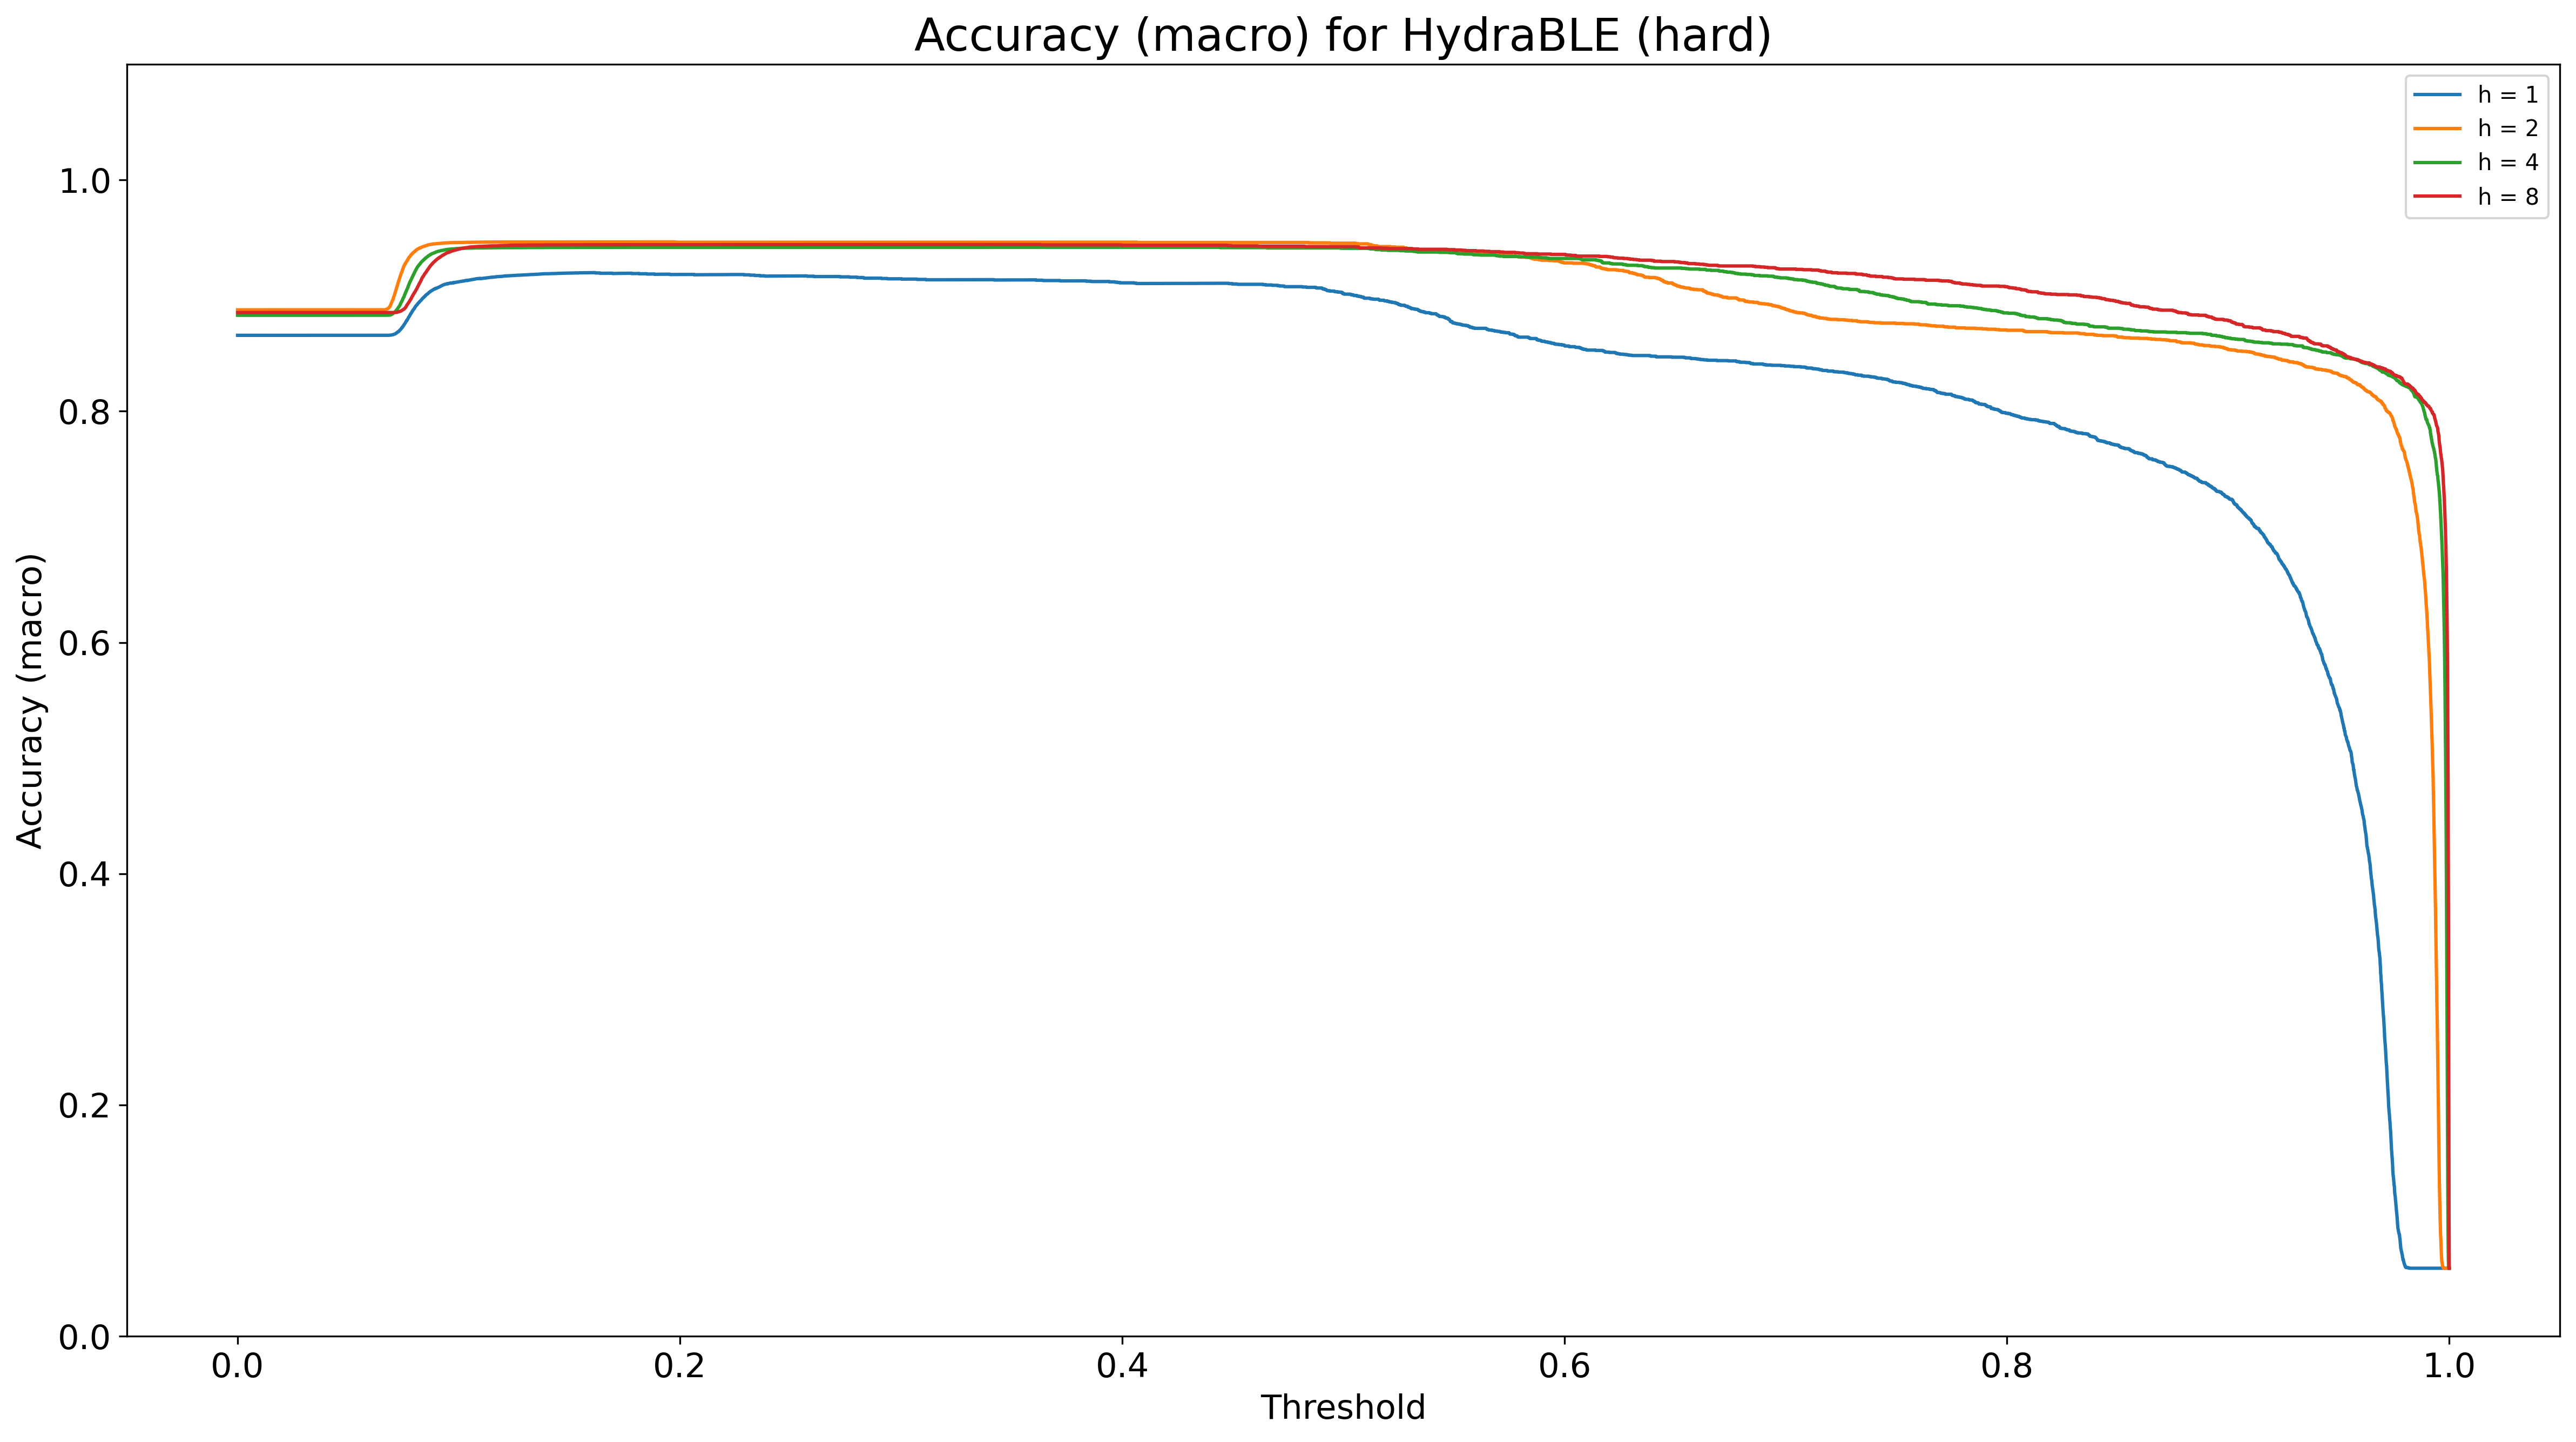

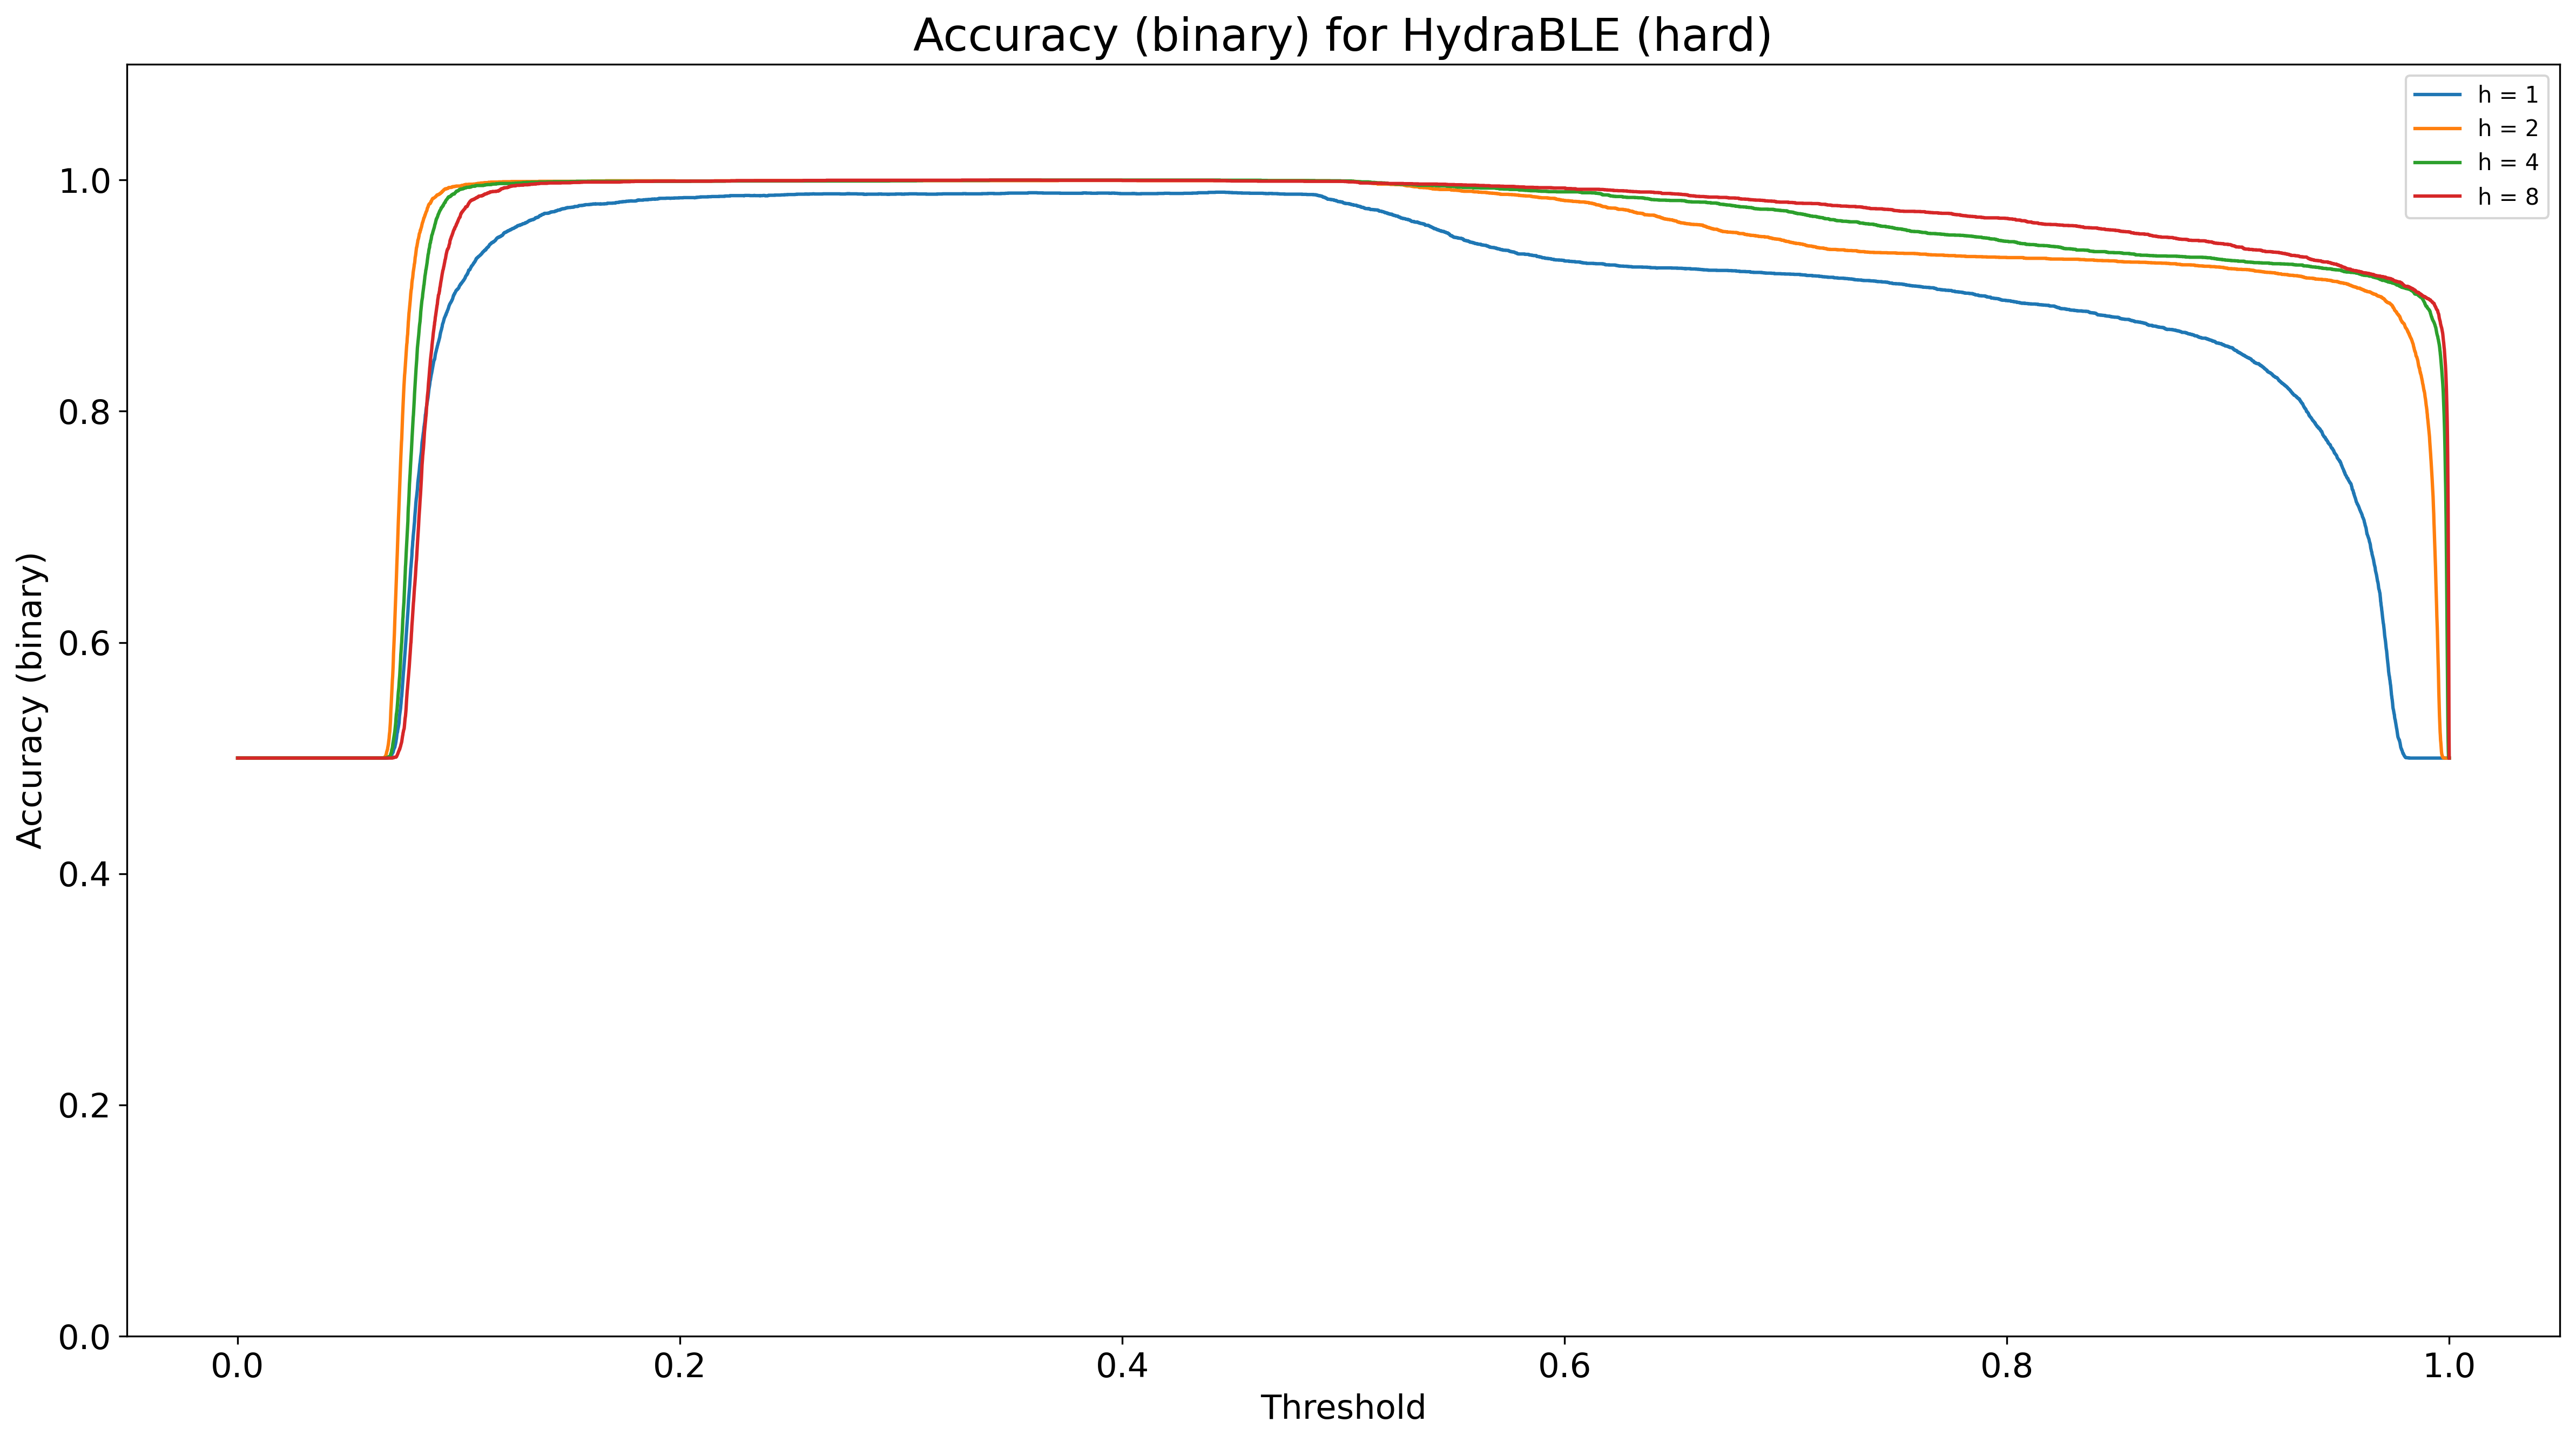

In [8]:
plot_curve(acc_micro_lut, "Accuracy (micro) for HydraBLE (hard)", "Accuracy (micro)")
plot_curve(acc_macro_lut, "Accuracy (macro) for HydraBLE (hard)", "Accuracy (macro)")
plot_curve(acc_binary_lut,  "Accuracy (binary) for HydraBLE (hard)", "Accuracy (binary)")

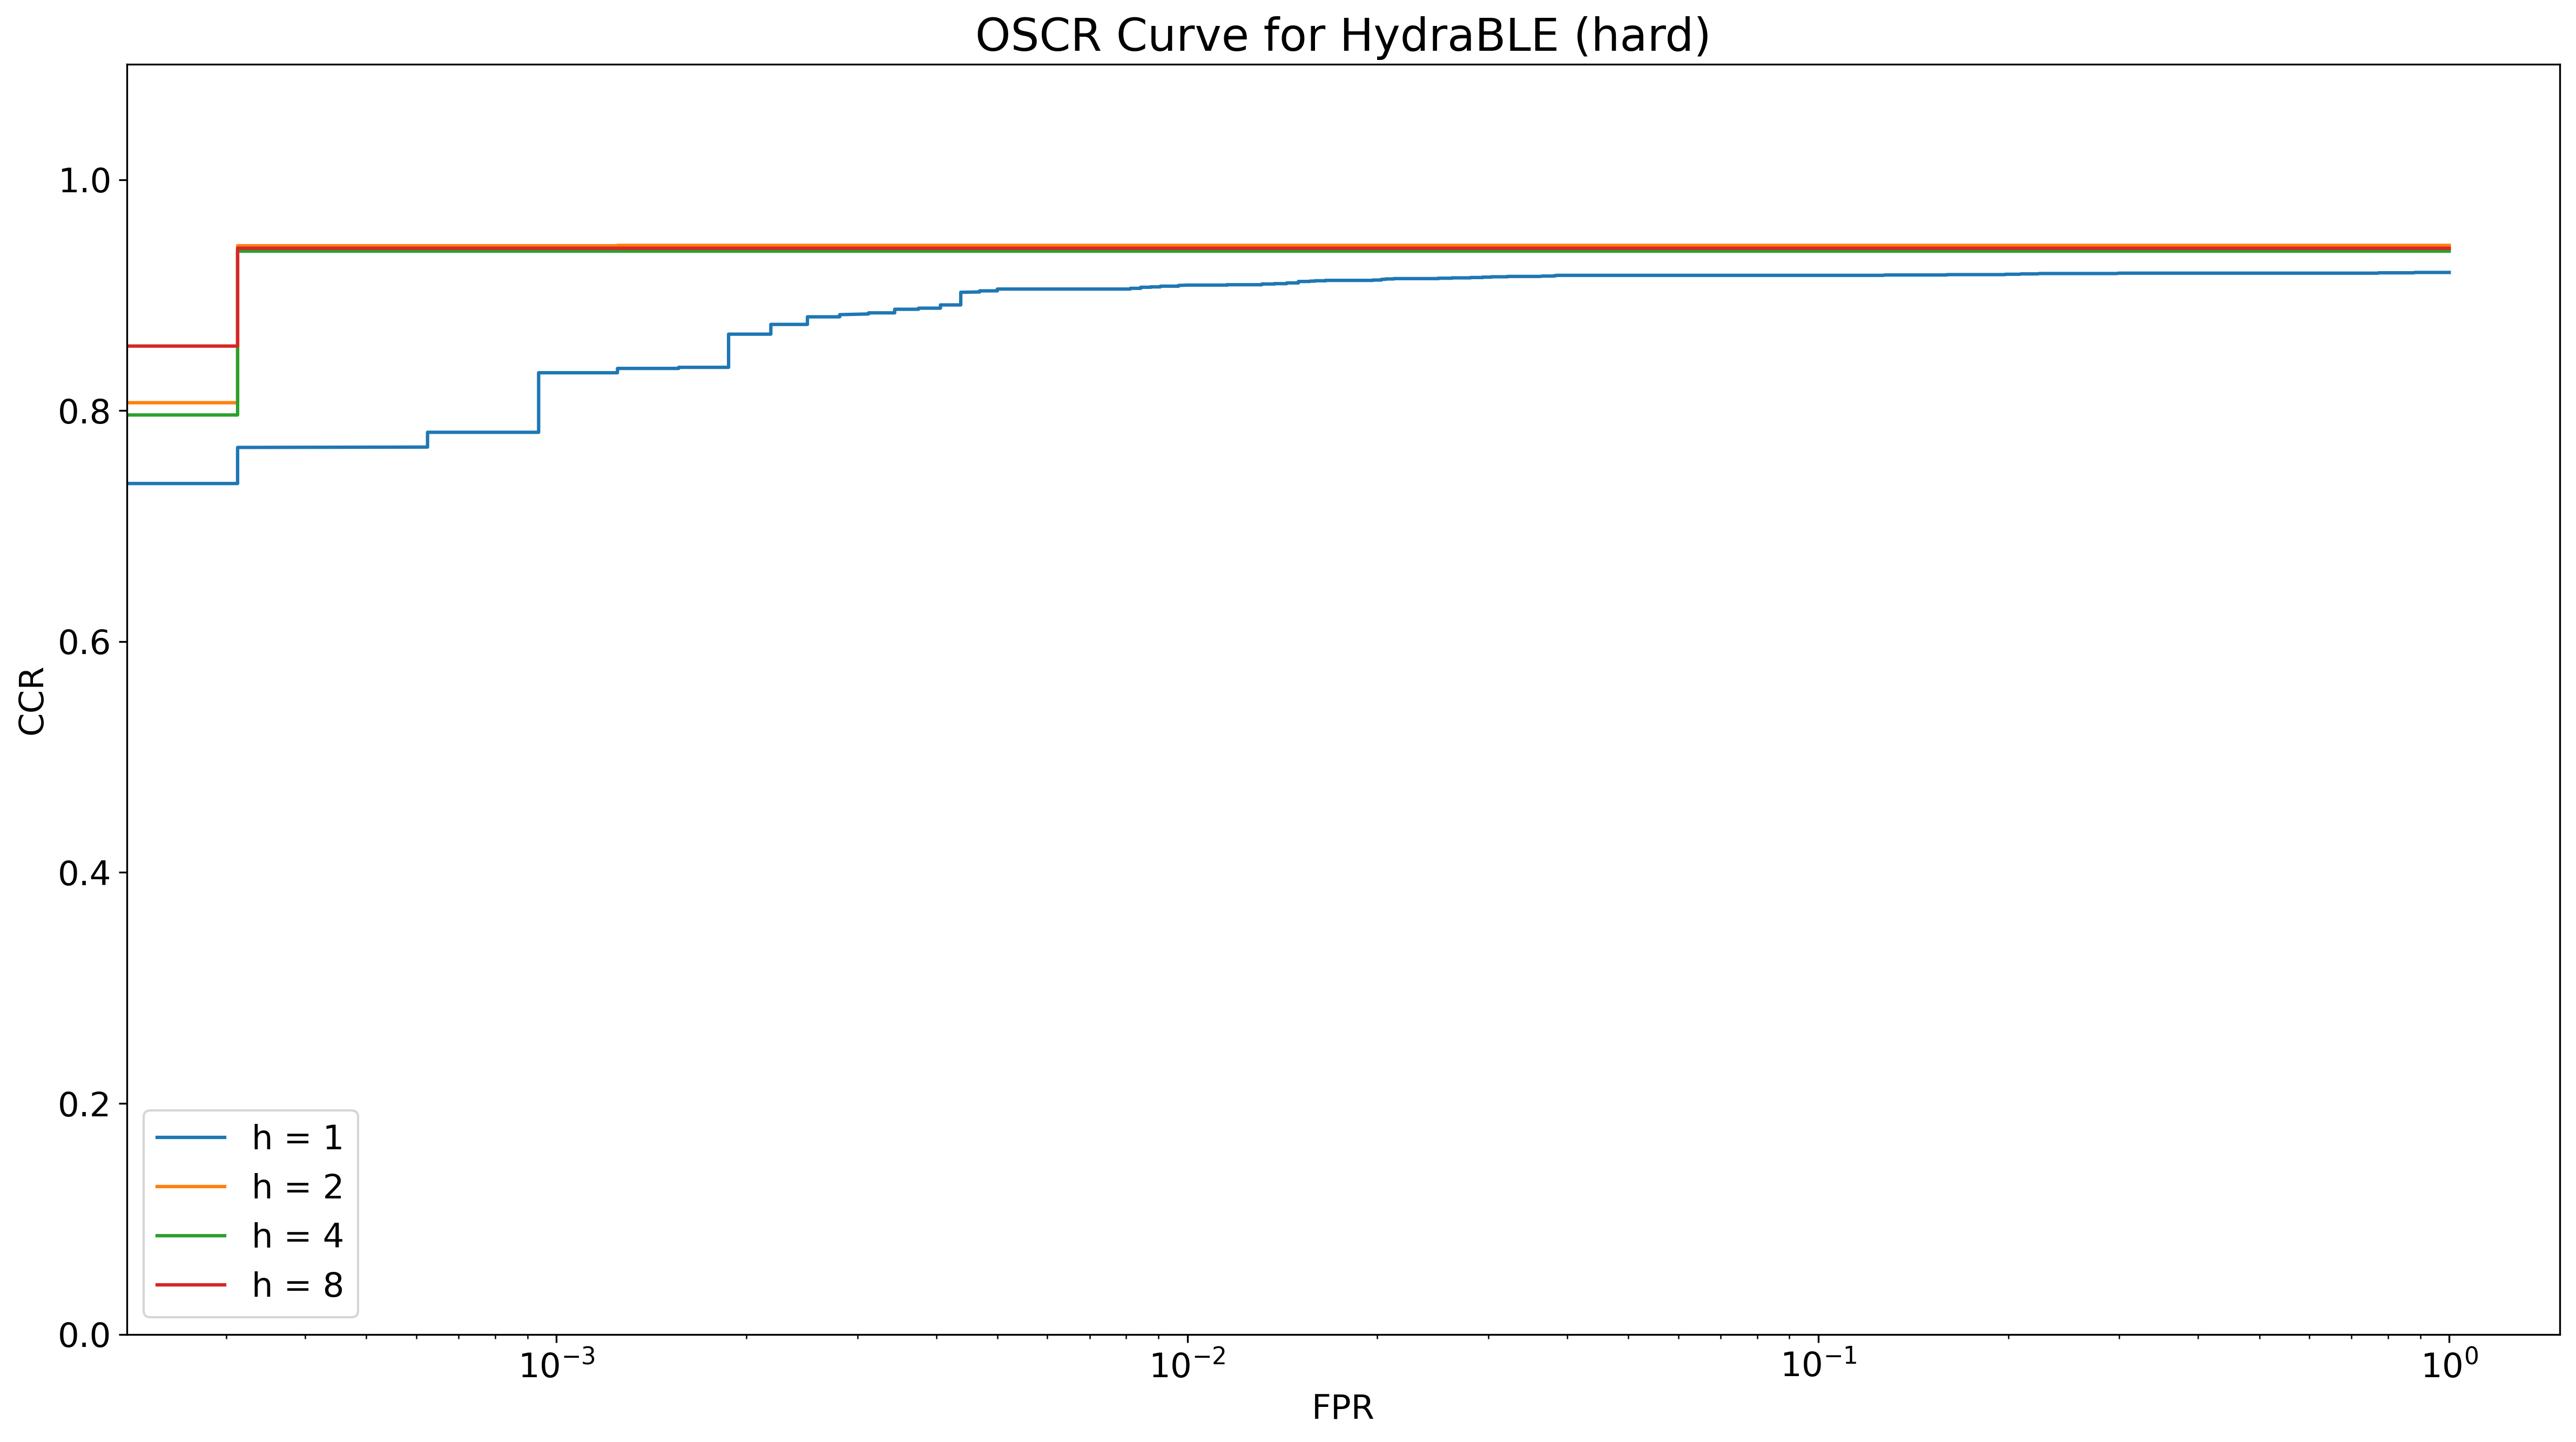

In [9]:

plt.figure(figsize=(16, 9), dpi = 300)

for h, values in oscr_lut.items():
    fprs = values[:, 0]
    ccrs = values[:, 1]

    plt.plot(fprs, ccrs, label=f"h = {h}")

plt.xticks(fontsize=FONTSIZE_TICKS)
plt.yticks(fontsize=FONTSIZE_TICKS)
plt.xlabel("Threshold", fontsize=FONTSIZE_LABEL)
plt.ylim(0, 1.1)
plt.xscale("log")
plt.ylabel("CCR", fontsize=FONTSIZE_LABEL)
plt.xlabel("FPR", fontsize=FONTSIZE_LABEL)
title = "OSCR Curve for HydraBLE (hard)"
plt.title(title, fontsize=FONTSIZE_TITLE)
plt.legend(fontsize=FONTSIZE_LABEL)
plt.tight_layout()
plt.savefig(plotPath + title + ".png", dpi = 300)
plt.show()

In [10]:
metrics = pd.DataFrame(np.array(metric_table).T, columns=("Metric", 1, 2, 4, 8))


In [11]:
metrics.to_csv(tablePath + "Metrics Table HydraBLE (hard).csv", index = False)

In [12]:
metrics

,Metric,1,2,4,8
0,Accuracy (micro),0.9481250047683716,0.9709374904632568,0.9681249856948853,0.9696875214576721
1,Accuracy (macro),0.9139338135719299,0.9463970065116882,0.9416544437408447,0.9440441131591797
2,Accuracy (binary),0.9878125190734863,0.999218761920929,0.9990624785423279,0.9993749856948853
3,CCR at FPR = 1e-1,0.917187511920929,0.9431250095367432,0.9381250143051147,0.940625011920929
4,CCR at FPR = 1e-2,0.9087499976158142,0.9431250095367432,0.9381250143051147,0.940625011920929
5,CCR at FPR = 1e-3,0.78125,0.9428125023841858,0.9381250143051147,0.940625011920929
